# Pipeline de Análisis Estadístico No Supervisado y Selección de Variables
# Base de Proyectos — Sistema General de Regalías (SGR)

---

## Descripción General

Este notebook implementa un pipeline de análisis exploratorio y **selección de variables no supervisada** sobre la base de datos de proyectos del Sistema General de Regalías (SGR), sin depender de una variable objetivo.

### Fundamento metodológico: Enfoque de Ensamble

La selección de variables mediante un único método estadístico es susceptible a sesgos y a la inestabilidad propia de cada técnica. Para mitigar esto, este pipeline adopta un **enfoque de ensamble de métodos de selección de variables** (*ensemble feature selection*), que combina los rankings de tres criterios complementarios e independientes:

| Método | Perspectiva que aporta |
|--------|------------------------|
| **Varianza Normalizada** | Discriminación global: variables con mayor dispersión informativa |
| **Importancia PCA (loadings)** | Estructura latente: variables que dominan la varianza compartida |
| **Laplacian Score** | Geometría local: variables que preservan la estructura de vecindad |

La consolidación mediante **promedio de rangos** (*rank aggregation*) es la estrategia estándar para combinar resultados heterogéneos: al trabajar sobre posiciones ordinales en lugar de valores crudos, se eliminan los problemas de escala y distribución entre métodos. Una variable que aparece consistentemente bien posicionada en los tres criterios ofrece mayor garantía de relevancia que una que destaca solo en uno.

> **Referencia principal sobre ensambles de selección de variables:**
> Saeys, Y., Abeel, T., & Van de Peer, Y. (2008). *Robust feature selection using ensemble feature selection techniques*. ECML/PKDD, Springer.
>
> **Marco teórico de consenso en feature selection:**
> Bolón-Canedo, V., & Alonso-Betanzos, A. (2019). *Ensembles for feature selection*. Springer International Publishing.

---

### Flujo del pipeline

1. **Fase 0** — Instalación de dependencias e importación de librerías  
2. **Fase 1** — Ingesta y estandarización del archivo Excel con estructura multinivel  
3. **Fase 1.2** — **(NUEVO)** Análisis Exploratorio de Calidad de Datos (completitud, distribuciones, outliers, correlaciones)  
4. **Fase 2** — Limpieza y preprocesamiento: nulos, imputación, varianza, codificación  
5. **Fase 3** — Correlación de Pearson y eliminación iterativa de multicolinealidad (VIF)  
6. **Fase 4** — PCA exploratorio, clustering jerárquico y K-Means  
7. **Fase 5** — Selección de variables: Varianza, PCA loadings y Laplacian Score  
8. **Fase 6** — Consolidación del ranking cruzado y exportación de resultados


## Fase 0 : Instalacion de Dependencias

Ejecutar esta celda unicamente si alguna de las librerias no esta instalada en el entorno.


In [1]:
# Descomentar segun sea necesario
!pip install pandas openpyxl scikit-learn matplotlib seaborn statsmodels scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Fase 0.1 : Importacion de Librerias


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import kneighbors_graph
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.sparse.csgraph import laplacian as csgraph_laplacian

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

print("Todas las librerias cargadas correctamente.")


Todas las librerias cargadas correctamente.


## Fase 0.2 : Variables Globales de Configuracion

Estos parametros controlan el comportamiento del pipeline. Modificarlos segun las
necesidades del analisis antes de ejecutar las celdas posteriores.


In [3]:
import os
import pathlib


# =====================================================================
# RUTAS — todas relativas a BASE_DIR
# =====================================================================
BASE_DIR = pathlib.Path().resolve().parents[1]
RUTA_EXCEL = BASE_DIR / 'data' / 'raw' / 'Base de proyectos _15_12_2025.xlsx'
RUTA_SALIDA = BASE_DIR / 'outputs' / 'rankings' / 'ranking_variables_capacidades.csv'

# =====================================================================
# PARÁMETROS DEL PIPELINE
# =====================================================================
HOJA                = "PROYECTOS APROBADOS "
HEADER_ROWS         = [5, 6]
UMBRAL_NULOS        = 0.60
UMBRAL_VARIANZA     = 0.01
UMBRAL_VIF          = 10
TOP_N               = 15
N_VECINOS_LAPLACIAN = 5
MAX_K_CLUSTERS      = 10
RANDOM_STATE        = 42
MAX_CARDINALIDAD    = 50

#print(f"BASE_DIR:    {BASE_DIR}")
#print(f"RUTA_EXCEL:  {RUTA_EXCEL}")
#print(f"RUTA_SALIDA: {RUTA_SALIDA}")
print(f"\nArchivo Excel: {'✅ encontrado' if RUTA_EXCEL.exists() else '❌ no encontrado — revisa data/raw/'}")
print("Variables globales configuradas.")



Archivo Excel: ✅ encontrado
Variables globales configuradas.


# Fase 1 : Ingesta y Estandarizacion

## Estrategia de Lectura

El archivo Excel presenta una estructura irregular con dos filas de encabezado.
La primera fila contiene headers de grupo (ej. CARACTERIZACION DEL PROYECTO,
APROBACION DEL PROYECTO, EJECUCION DEL PROYECTO, FUENTES DE FINANCIACION) y
la segunda fila contiene los nombres individuales de cada columna (ej. BPIN,
VALOR SGP, VALOR SGR).

La funcion de ingesta lee ambas filas como MultiIndex y luego aplana los nombres
de columna concatenando el nivel de grupo con el nombre individual. Los niveles
"Unnamed" generados por celdas fusionadas se omiten automaticamente.


In [4]:
def ingestar_excel(ruta, hoja, header_rows, skiprows=None, usecols=None):
    """
    Lee un archivo Excel con estructura irregular y aplana headers multinivel.

    Parametros
    ----------
    ruta : str
        Ruta al archivo .xlsx.
    hoja : str
        Nombre de la hoja a leer.
    header_rows : list[int]
        Indices (0-based) de las filas que contienen los encabezados.
    skiprows : list[int] o None
        Filas adicionales a omitir durante la lectura.
    usecols : str, list o None
        Columnas especificas a leer (ej. "A:Z" o [0,1,2]).

    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas aplanadas y tipos inferidos.
    """
    df = pd.read_excel(
        ruta,
        sheet_name=hoja,
        header=header_rows,
        skiprows=skiprows,
        usecols=usecols,
        engine="openpyxl"
    )

    # --- Aplanamiento de MultiIndex en columnas ---
    if isinstance(df.columns, pd.MultiIndex):
        nuevas_columnas = []
        for niveles in df.columns:
            partes = []
            for parte in niveles:
                s = str(parte).strip()
                if "Unnamed" not in s:
                    partes.append(s)
            nombre = "_".join(partes) if partes else "SIN_NOMBRE"
            nuevas_columnas.append(nombre)
        df.columns = nuevas_columnas
    else:
        df.columns = [str(c).strip() for c in df.columns]

    # Eliminar columnas y filas completamente vacias
    df = df.dropna(axis=1, how="all")
    df = df.dropna(axis=0, how="all")
    df = df.reset_index(drop=True)

    return df


# --- Ejecutar ingesta ---
df_raw = ingestar_excel(
    ruta=RUTA_EXCEL,
    hoja=HOJA,
    header_rows=HEADER_ROWS
)

print(f"Dimensiones del DataFrame crudo: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")

Dimensiones del DataFrame crudo: 35388 filas x 152 columnas


## Fase 1.1 : Inspeccion Inicial del DataFrame

Revision de tipos de datos, conteo de nulos por columna, distribucion de grupos
tematicos (segun el prefijo del header de grupo) y estadisticas descriptivas
para comprender la calidad de los datos antes de la limpieza.


In [5]:
# Resumen de tipos y nulos
print("=" * 70)
print("RESUMEN DE TIPOS DE DATOS Y NULIDAD")
print("=" * 70)

resumen = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "no_nulos": df_raw.count(),
    "nulos": df_raw.isnull().sum(),
    "pct_nulos": (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    "unicos": df_raw.nunique()
})
resumen = resumen.sort_values("pct_nulos", ascending=False)

# Mostrar solo las que tienen nulos
con_nulos = resumen[resumen["nulos"] > 0]
print(f"\nColumnas con algun valor nulo ({len(con_nulos)} de {len(resumen)}):")
#print(con_nulos.to_string())

print(f"\n{'=' * 70}")
print(f"Total columnas: {df_raw.shape[1]}")
print(f"Total filas: {df_raw.shape[0]}")
print(f"Columnas con >{UMBRAL_NULOS*100:.0f}% nulos: {(resumen['pct_nulos'] > UMBRAL_NULOS * 100).sum()}")
print(f"Columnas sin ningun nulo: {(resumen['nulos'] == 0).sum()}")


RESUMEN DE TIPOS DE DATOS Y NULIDAD

Columnas con algun valor nulo (55 de 152):

Total columnas: 152
Total filas: 35388
Columnas con >60% nulos: 32
Columnas sin ningun nulo: 97


In [6]:
# Distribucion por grupo tematico (prefijo antes del primer '_')
grupos = [c.split("_")[0] if "_" in c else "SIN_GRUPO" for c in df_raw.columns]
print(f"\nDistribucion por grupo tematico:")
for g, n in pd.Series(grupos).value_counts().items():
    print(f"  {g}: {n} columnas")


Distribucion por grupo tematico:
  FUENTES DE FINANCIACIÓN DETALLADAS: 42 columnas
  CARACTERIZACIÓN DEL PROYECTO: 41 columnas
  EJECUCIÓN DEL PROYECTO: 31 columnas
  ENTIDAD EJECUTORA DEL PROYECTO: 11 columnas
  APROBACIÓN DEL PROYECTO: 10 columnas
  FUENTES DE FINANCIACIÓN CONSOLIDADAS: 8 columnas
  CONTROL SOCIAL DEL PROYECTO: 7 columnas
  OTRAS VARIABLES DEL PROYECTO: 2 columnas


## Fase 1.2 : Análisis Exploratorio de Calidad de Datos (EDA)

Esta fase implementa un diagnóstico formal de calidad antes de cualquier transformación. El objetivo es documentar el estado real del dataset y detectar:

- **Completitud**: porcentaje de valores faltantes por variable y por grupo temático.
- **Distribución**: asimetría, curtosis y presencia de valores atípicos en variables numéricas.
- **Consistencia**: cardinalidad de variables categóricas y detección de categorías raras.
- **Estructura de correlaciones**: mapa de calor de correlaciones para identificar redundancia antes del VIF.

> Han, J., Kamber, M., & Pei, J. (2012). *Data Mining: Concepts and Techniques* (3.ª ed.). Morgan Kaufmann. — Capítulos 2 y 3 sobre preprocesamiento y calidad de datos.


DIAGNÓSTICO DE CALIDAD DE DATOS

[1] COMPLETITUD — Total columnas: 152, Total filas: 35388
    Columnas con >60% nulos : 32
    Columnas con >30% nulos : 34
    Columnas sin ningún nulo: 97

    Distribución de columnas por porcentaje de nulos:
    Sin nulos:  97 cols  █████████████████████████
       1-10%:  21 cols  █████
      10-30%:   0 cols  
      30-60%:   2 cols  
        >60%:  32 cols  ████████

    Nulidad promedio por grupo temático:
    APROBACIÓN DEL PROYECTO                                :   1.0% nulos promedio (10 cols)
    CARACTERIZACIÓN DEL PROYECTO                           :  75.7% nulos promedio (41 cols)
    CONTROL SOCIAL DEL PROYECTO                            :   0.0% nulos promedio (7 cols)
    EJECUCIÓN DEL PROYECTO                                 :   0.0% nulos promedio (31 cols)
    ENTIDAD EJECUTORA DEL PROYECTO                         :   0.1% nulos promedio (11 cols)
    FUENTES DE FINANCIACIÓN CONSOLIDADAS                   :   0.0% nulos promedio (8

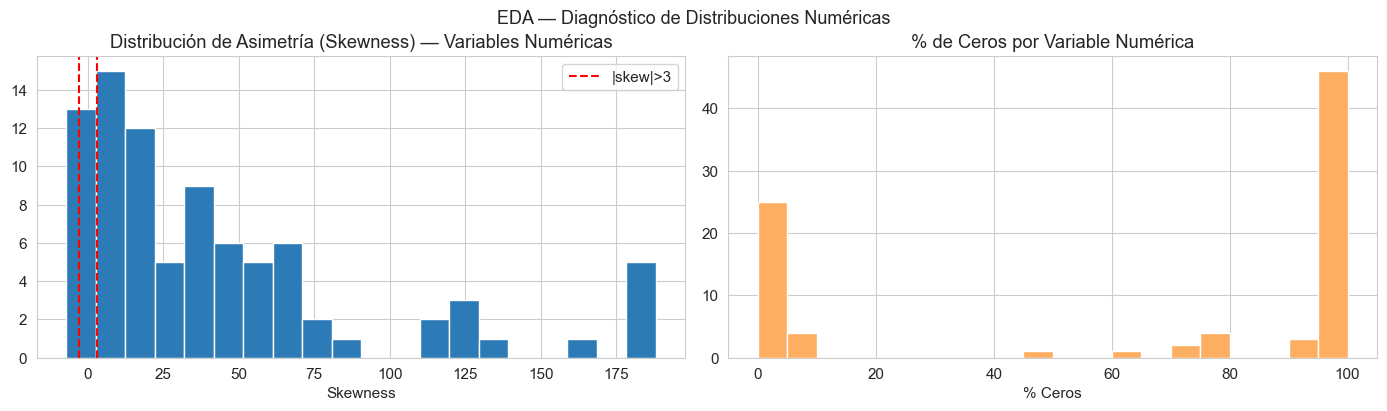


[3] CONSISTENCIA CATEGÓRICA — 48 variables categóricas
    Variables con cardinalidad >50 (alta): 10
    Variables con cardinalidad <=5 (baja): 18
    Variables donde 1 categoría >80% frecuencia (cuasi-constante): 15

[4] ESTRUCTURA DE CORRELACIONES — PRE-LIMPIEZA
    Pares con |correlación| > 0.85 (pre-limpieza): 36
    → Estos serán tratados en la Fase 3 (VIF iterativo)


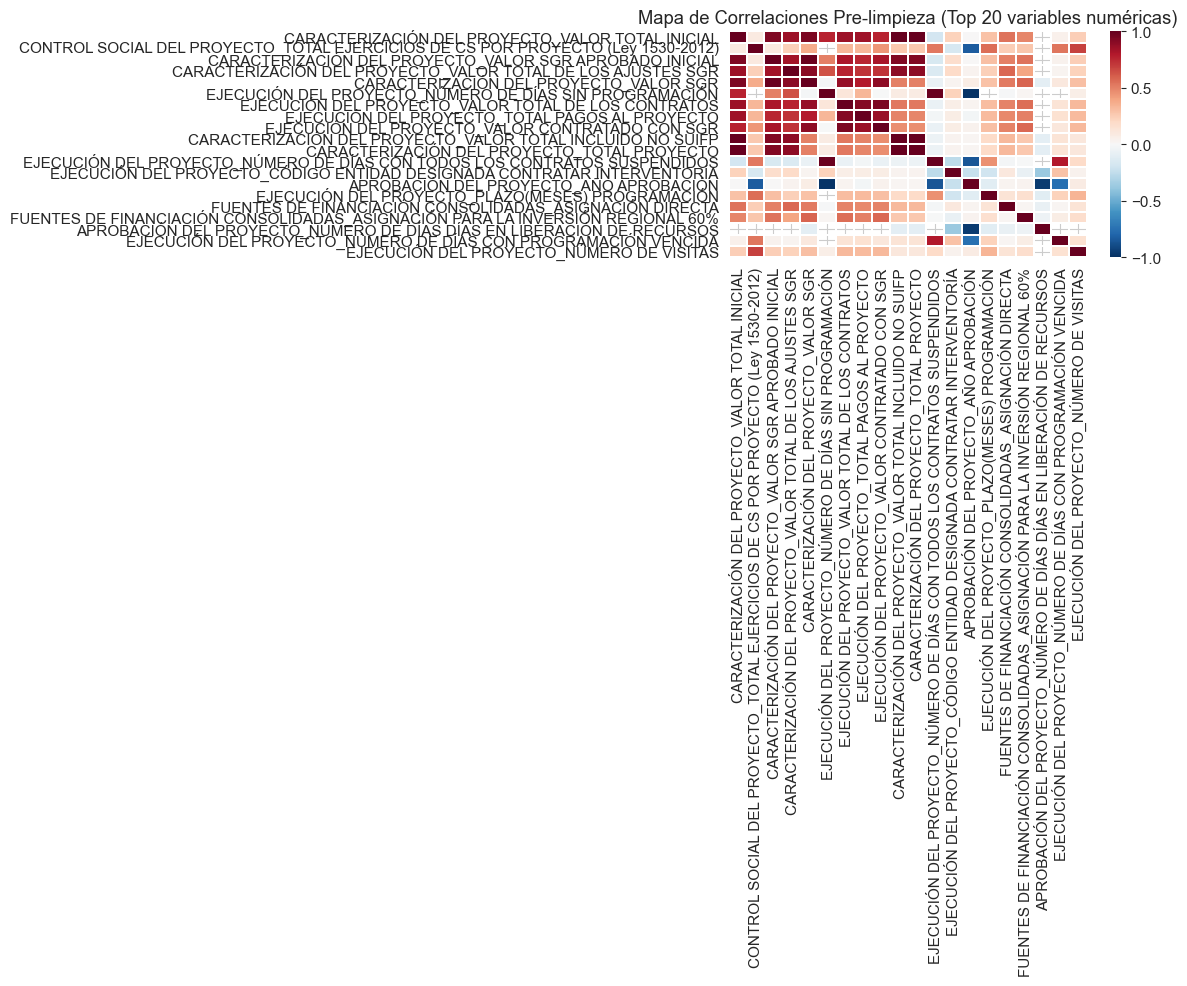


✅ EDA de calidad completado. Resumen disponible para el informe técnico.


In [7]:
# =====================================================================
# FASE 1.2 : ANÁLISIS EXPLORATORIO DE CALIDAD DE DATOS (EDA)
# =====================================================================

print("=" * 70)
print("DIAGNÓSTICO DE CALIDAD DE DATOS")
print("=" * 70)

# ------------------------------------------------------------------
# 1. COMPLETITUD POR COLUMNA Y POR GRUPO TEMÁTICO
# ------------------------------------------------------------------
pct_nulos_col = (df_raw.isnull().mean() * 100).round(2).sort_values(ascending=False)
print(f"\n[1] COMPLETITUD — Total columnas: {df_raw.shape[1]}, Total filas: {df_raw.shape[0]}")
print(f"    Columnas con >60% nulos : {(pct_nulos_col > 60).sum()}")
print(f"    Columnas con >30% nulos : {(pct_nulos_col > 30).sum()}")
print(f"    Columnas sin ningún nulo: {(pct_nulos_col == 0).sum()}")

# Distribución de nulidad por rango
rangos = [(0, 0), (0, 10), (10, 30), (30, 60), (60, 100)]
etiquetas = ["Sin nulos", "1-10%", "10-30%", "30-60%", ">60%"]
print("\n    Distribución de columnas por porcentaje de nulos:")
for (lo, hi), etiq in zip(rangos, etiquetas):
    if lo == 0 and hi == 0:
        n = (pct_nulos_col == 0).sum()
    else:
        n = ((pct_nulos_col > lo) & (pct_nulos_col <= hi)).sum()
    bar = "█" * int(n / max(df_raw.shape[1], 1) * 40)
    print(f"    {etiq:>8}: {n:3d} cols  {bar}")

# Nulidad por grupo temático
grupos_raw = [c.split("_")[0] if "_" in c else "SIN_GRUPO" for c in df_raw.columns]
df_grupos = pd.DataFrame({"col": df_raw.columns, "grupo": grupos_raw, "pct_nulos": pct_nulos_col.values})
print("\n    Nulidad promedio por grupo temático:")
for g, sub in df_grupos.groupby("grupo"):
    avg = sub["pct_nulos"].mean()
    print(f"    {g:55s}: {avg:5.1f}% nulos promedio ({len(sub)} cols)")

# ------------------------------------------------------------------
# 2. DISTRIBUCIÓN DE VARIABLES NUMÉRICAS — ASIMETRÍA Y CURTOSIS
# ------------------------------------------------------------------
cols_num_eda = df_raw.select_dtypes(include=[np.number]).columns
print(f"\n[2] DISTRIBUCIÓN NUMÉRICA — {len(cols_num_eda)} variables numéricas")

if len(cols_num_eda) > 0:
    desc_stats = df_raw[cols_num_eda].describe().T
    desc_stats["skewness"]  = df_raw[cols_num_eda].skew()
    desc_stats["kurtosis"]  = df_raw[cols_num_eda].kurtosis()
    desc_stats["pct_cero"]  = ((df_raw[cols_num_eda] == 0).mean() * 100).round(1)

    muy_asim = desc_stats[desc_stats["skewness"].abs() > 3]
    print(f"    Variables con |asimetría| > 3 (distribución muy sesgada): {len(muy_asim)}")
    if len(muy_asim) > 0 and len(muy_asim) <= 10:
        print(muy_asim[["skewness", "kurtosis", "pct_cero"]].to_string())
    elif len(muy_asim) > 10:
        print(muy_asim.head(10)[["skewness", "kurtosis", "pct_cero"]].to_string())
        print(f"    ... y {len(muy_asim) - 10} más.")

    # Visualización: distribución de asimetría
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(desc_stats["skewness"].dropna(), bins=20, color="#2c7bb6", edgecolor="white")
    axes[0].axvline(3, color="red", linestyle="--", label="|skew|>3")
    axes[0].axvline(-3, color="red", linestyle="--")
    axes[0].set_title("Distribución de Asimetría (Skewness) — Variables Numéricas")
    axes[0].set_xlabel("Skewness")
    axes[0].legend()

    axes[1].hist(desc_stats["pct_cero"].dropna(), bins=20, color="#fdae61", edgecolor="white")
    axes[1].set_title("% de Ceros por Variable Numérica")
    axes[1].set_xlabel("% Ceros")

    plt.tight_layout()
    plt.suptitle("EDA — Diagnóstico de Distribuciones Numéricas", y=1.02, fontsize=13)
    plt.show()

# ------------------------------------------------------------------
# 3. CONSISTENCIA CATEGÓRICA — CARDINALIDAD Y CATEGORÍAS RARAS
# ------------------------------------------------------------------
cols_cat_eda = df_raw.select_dtypes(include=["object", "category"]).columns
print(f"\n[3] CONSISTENCIA CATEGÓRICA — {len(cols_cat_eda)} variables categóricas")

if len(cols_cat_eda) > 0:
    resumen_cat = pd.DataFrame({
        "n_unicos":    [df_raw[c].nunique() for c in cols_cat_eda],
        "pct_mas_frec": [df_raw[c].value_counts(normalize=True).iloc[0] * 100 if df_raw[c].count() > 0 else 0 for c in cols_cat_eda],
    }, index=cols_cat_eda).sort_values("n_unicos", ascending=False)

    print(f"    Variables con cardinalidad >50 (alta): {(resumen_cat['n_unicos'] > 50).sum()}")
    print(f"    Variables con cardinalidad <=5 (baja): {(resumen_cat['n_unicos'] <= 5).sum()}")
    print(f"    Variables donde 1 categoría >80% frecuencia (cuasi-constante): "
          f"{(resumen_cat['pct_mas_frec'] > 80).sum()}")

# ------------------------------------------------------------------
# 4. MAPA DE CORRELACIONES — PRE-LIMPIEZA
# ------------------------------------------------------------------
print(f"\n[4] ESTRUCTURA DE CORRELACIONES — PRE-LIMPIEZA")

cols_num_corr = df_raw.select_dtypes(include=[np.number]).columns
if len(cols_num_corr) >= 4:
    corr_pre = df_raw[cols_num_corr].corr(method="pearson")
    alta_corr_pre = 0
    for i in range(len(corr_pre.columns)):
        for j in range(i + 1, len(corr_pre.columns)):
            if abs(corr_pre.iloc[i, j]) > 0.85:
                alta_corr_pre += 1
    print(f"    Pares con |correlación| > 0.85 (pre-limpieza): {alta_corr_pre}")
    print(f"    → Estos serán tratados en la Fase 3 (VIF iterativo)")

    n_show = min(20, len(cols_num_corr))
    top_c = corr_pre.abs().mean().sort_values(ascending=False).head(n_show).index
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_pre.loc[top_c, top_c], annot=False, cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax)
    ax.set_title(f"Mapa de Correlaciones Pre-limpieza (Top {n_show} variables numéricas)")
    plt.tight_layout()
    plt.show()
else:
    print("    Insuficientes variables numéricas para mapa de correlaciones pre-limpieza.")

print("\n✅ EDA de calidad completado. Resumen disponible para el informe técnico.")


# Fase 2 : Limpieza y Preprocesamiento

## Fase 2.1 : Eliminación de Columnas por Umbral de Nulidad

Se descartan automáticamente las columnas cuyo porcentaje de valores nulos supere el umbral definido en `UMBRAL_NULOS` (por defecto, **60%**).

**Justificación del umbral del 60%:**
Imputar columnas con más del 60% de datos faltantes introduce un sesgo estructural en cualquier análisis no supervisado: la mayoría de los valores serían imputados, no observados, convirtiendo la variable en una representación de la estrategia de imputación y no del fenómeno real. El umbral del 60% es un punto de corte ampliamente utilizado en la literatura de preprocesamiento de datos ([Han et al., 2012]()), que balancea la conservación de información frente al riesgo de introducir artefactos estadísticos. Para el análisis supervisado posterior podría usarse un umbral más conservador (40%).

> Han, J., Kamber, M., & Pei, J. (2012). *Data Mining: Concepts and Techniques* (3.ª ed.). Morgan Kaufmann. — §3.2 Data Cleaning.


In [8]:
def eliminar_columnas_por_nulidad(df, umbral):
    """
    Elimina columnas cuyo porcentaje de valores nulos supere el umbral.

    Retorna
    -------
    pd.DataFrame, list
        DataFrame filtrado y lista de columnas eliminadas.
    """
    pct_nulos = df.isnull().mean()
    cols_eliminar = pct_nulos[pct_nulos > umbral].index.tolist()

    print(f"Columnas eliminadas por superar {umbral*100:.0f}% de nulos: {len(cols_eliminar)}")
    if len(cols_eliminar) <= 20:
        for col in cols_eliminar:
            print(f"  - {col}: {pct_nulos[col]*100:.1f}% nulos")
    else:
        for col in cols_eliminar[:10]:
            print(f"  - {col}: {pct_nulos[col]*100:.1f}% nulos")
        print(f"  ... y {len(cols_eliminar) - 10} columnas mas.")

    df_limpio = df.drop(columns=cols_eliminar)
    return df_limpio, cols_eliminar


df_filtrado, cols_eliminadas_nulos = eliminar_columnas_por_nulidad(df_raw, UMBRAL_NULOS)
print(f"\nDimensiones tras filtro de nulidad: {df_filtrado.shape}")


Columnas eliminadas por superar 60% de nulos: 32
  - CARACTERIZACIÓN DEL PROYECTO_PROGRAMAS DE DESARROLLO CON ENFOQUE TERRITORIAL - PDET (SEGÚN ENTIDAD EJECUTORA): 90.0% nulos
  - CARACTERIZACIÓN DEL PROYECTO_SUBREGIONES PDET PROYECTOS APROBADOS OCAD PAZ (SEGÚN LOCALIZACIÓN): 97.5% nulos
  - CARACTERIZACIÓN DEL PROYECTO_CONSOLIDADO PDET: 88.9% nulos
  - CARACTERIZACIÓN DEL PROYECTO_VALOR TOTAL INICIAL: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_VALOR SGR APROBADO INICIAL: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_TIENE AJUSTES POR MONTO SGR: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_CUANTOS AJUSTES PRESENTA POR VALOR SGR: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_VALOR TOTAL DE LOS AJUSTES SGR: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_ÚLTIMA FECHA DE AJUSTE: 89.6% nulos
  - CARACTERIZACIÓN DEL PROYECTO_TRANSFORMACIONES PLAN NACIONAL DE DESARROLLO: 70.3% nulos
  ... y 22 columnas mas.

Dimensiones tras filtro de nulidad: (35388, 120)


## Fase 2.2 : Imputacion de Valores Faltantes Residuales

Para columnas numericas con nulos residuales se aplica imputacion por mediana
(robusta frente a valores atipicos, frecuentes en datos presupuestales).
Para columnas categoricas, se imputa con la moda o con "SIN_DATO".


In [9]:
def imputar_nulos(df):
    """
    Imputa valores nulos:
    - Numericas: mediana.
    - Categoricas: moda o 'SIN_DATO'.

    Retorna
    -------
    pd.DataFrame, dict
        DataFrame imputado y registro de imputaciones.
    """
    registro = {}
    df_imp = df.copy()

    # Numericas
    cols_num = df_imp.select_dtypes(include=[np.number]).columns
    for col in cols_num:
        n_nulos = df_imp[col].isnull().sum()
        if n_nulos > 0:
            mediana = df_imp[col].median()
            df_imp[col] = df_imp[col].fillna(mediana)
            registro[col] = {"metodo": "mediana", "valor": mediana, "n": n_nulos}

    # Categoricas
    cols_cat = df_imp.select_dtypes(include=["object", "string", "category"]).columns
    for col in cols_cat:
        n_nulos = df_imp[col].isnull().sum()
        if n_nulos > 0:
            moda = df_imp[col].mode()
            valor_imp = moda.iloc[0] if len(moda) > 0 else "SIN_DATO"
            df_imp[col] = df_imp[col].fillna(valor_imp)
            registro[col] = {"metodo": "moda", "valor": valor_imp, "n": n_nulos}

    # Fechas: imputar con la mediana de la columna datetime
    cols_dt = df_imp.select_dtypes(include=["datetime64"]).columns
    for col in cols_dt:
        n_nulos = df_imp[col].isnull().sum()
        if n_nulos > 0:
            mediana_dt = df_imp[col].dropna().median()
            df_imp[col] = df_imp[col].fillna(mediana_dt)
            registro[col] = {"metodo": "mediana_fecha", "valor": str(mediana_dt), "n": n_nulos}

    print(f"Variables imputadas: {len(registro)}")
    for k, v in list(registro.items())[:10]:
        print(f"  {k}: {v['metodo']} = {v['valor']} ({v['n']} nulos)")
    if len(registro) > 10:
        print(f"  ... y {len(registro) - 10} mas.")

    return df_imp, registro


df_imputado, registro_imputacion = imputar_nulos(df_filtrado)
assert df_imputado.isnull().sum().sum() == 0, "ERROR: Quedan valores nulos."
print(f"\nVerificacion: 0 nulos restantes. OK.")
print(f"Dimensiones: {df_imputado.shape}")


Variables imputadas: 23
  ENTIDAD EJECUTORA DEL PROYECTO_DIGITO VERIFICACIÓN: mediana = 4.0 (216 nulos)
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: mediana = 3.0 (217 nulos)
  EJECUCIÓN DEL PROYECTO_NUMERO DE CONTRATOS ASOCIADOS AL PROYECTO: mediana = 2.0 (1356 nulos)
  EJECUCIÓN DEL PROYECTO_NUMERO DE CONTRATOS SUSPENDIDOS: mediana = 0.0 (1356 nulos)
  EJECUCIÓN DEL PROYECTO_NUMERO DE CONTRATOS VIGENTES: mediana = 2.0 (1356 nulos)
  EJECUCIÓN DEL PROYECTO_PLAZO(MESES) PROGRAMACIÓN: mediana = 7.0 (1319 nulos)
  CARACTERIZACIÓN DEL PROYECTO_ALCANCE: moda = NO APLICA (10672 nulos)
  CARACTERIZACIÓN DEL PROYECTO_FASE DEL PROYECTO: moda = FACTIBILIDAD - FASE 3 (11 nulos)
  CARACTERIZACIÓN DEL PROYECTO_DESTINO DE RECURSOS 
(Según la fase del proyecto): moda = EJECUCION (11 nulos)
  ENTIDAD EJECUTORA DEL PROYECTO_REGION EJECUTOR: moda = CARIBE (216 nulos)
  ... y 13 mas.

Verificacion: 0 nulos restantes. OK.
Dimensiones: (35388, 120)


## Fase 2.3 : Eliminación de Variables con Varianza Cercana a Cero

Las variables constantes o cuasi-constantes no aportan información discriminante: si una variable toma el mismo valor (o casi el mismo) para todos los proyectos, es imposible que ayude a diferenciarlos.

**Justificación del proceso de normalización Min-Max antes del cálculo de varianza:**
Las columnas numéricas tienen escalas muy distintas (por ejemplo, valores presupuestales en millones de pesos vs. indicadores binarios 0/1). Comparar varianzas crudas entre variables de escalas diferentes es inválido estadísticamente. La normalización al rango [0, 1] mediante Min-Max Scaling hace comparables las varianzas:

$$v_{norm} = \frac{v - v_{min}}{v_{max} - v_{min}}$$

> Han, J., Kamber, M., & Pei, J. (2012). *Data Mining: Concepts and Techniques* (3.ª ed.). Morgan Kaufmann. — §3.5 Data Transformation and Data Discretization (normalización Min-Max).

**Umbral de varianza = 0.01:** Una variable con varianza normalizada inferior a 0.01 exhibe una dispersión tan reducida que prácticamente no diferencia observaciones. Este umbral es conservador: se preservan variables con variación mínima pero no nula.


In [10]:
def eliminar_baja_varianza(df, umbral_var):
    """
    Elimina columnas numericas con varianza normalizada < umbral
    y categoricas con un unico valor.

    Retorna
    -------
    pd.DataFrame, list
    """
    cols_eliminar = []

    # Numericas
    cols_num = df.select_dtypes(include=[np.number]).columns
    for col in cols_num:
        rango = df[col].max() - df[col].min()
        if rango == 0:
            cols_eliminar.append(col)
        else:
            normalizado = (df[col] - df[col].min()) / rango
            if normalizado.var() < umbral_var:
                cols_eliminar.append(col)

    # Categoricas con un unico valor
    cols_cat = df.select_dtypes(include=["object", "string", "category"]).columns
    for col in cols_cat:
        if df[col].nunique() <= 1:
            cols_eliminar.append(col)

    print(f"Columnas eliminadas por baja varianza: {len(cols_eliminar)}")
    if len(cols_eliminar) <= 15:
        for col in cols_eliminar:
            print(f"  - {col}")
    else:
        for col in cols_eliminar[:10]:
            print(f"  - {col}")
        print(f"  ... y {len(cols_eliminar) - 10} mas.")

    df_out = df.drop(columns=cols_eliminar)
    return df_out, cols_eliminar


df_var, cols_eliminadas_var = eliminar_baja_varianza(df_imputado, UMBRAL_VARIANZA)
print(f"\nDimensiones tras filtro de varianza: {df_var.shape}")


Columnas eliminadas por baja varianza: 68
  - CARACTERIZACIÓN DEL PROYECTO_PGN
  - CARACTERIZACIÓN DEL PROYECTO_PROPIOS
  - CARACTERIZACIÓN DEL PROYECTO_VALOR SGP
  - CARACTERIZACIÓN DEL PROYECTO_VALOR TOTAL INCLUIDO NO SUIFP
  - CARACTERIZACIÓN DEL PROYECTO_VALOR SGR
  - CARACTERIZACIÓN DEL PROYECTO_VALOR NACIÓN
  - CARACTERIZACIÓN DEL PROYECTO_VALOR OTROS
  - CARACTERIZACIÓN DEL PROYECTO_TOTAL PROYECTO
  - CARACTERIZACIÓN DEL PROYECTO_VALOR NO SUIFP
  - ENTIDAD EJECUTORA DEL PROYECTO_NIT ENTIDAD EJECUTORA
  ... y 58 mas.

Dimensiones tras filtro de varianza: (35388, 52)


## Fase 2.4 : Codificacion de Variables Categoricas

Se aplica Label Encoding a columnas categoricas con cardinalidad moderada
(menos de MAX_CARDINALIDAD categorias unicas). Las columnas de alta cardinalidad
como nombres de proyecto, localizaciones libres o entidades ejecutoras se excluyen
del analisis numerico por no ser representables sin perdida de informacion
en un esquema ordinal.


In [11]:
def codificar_categoricas(df, max_cardinalidad=50):
    """
    Label Encoding para categoricas con cardinalidad <= max_cardinalidad.
    Excluye columnas de alta cardinalidad.

    Retorna
    -------
    pd.DataFrame, list, dict
    """
    df_cod = df.copy()
    cols_excluidas = []
    encoders = {}

    cols_cat = df_cod.select_dtypes(include=["object", "string", "category"]).columns

    for col in cols_cat:
        n_unicos = df_cod[col].nunique()
        if n_unicos > max_cardinalidad:
            cols_excluidas.append(col)
            print(f"  Excluida (cardinalidad={n_unicos}): {col}")
        else:
            le = LabelEncoder()
            df_cod[col] = le.fit_transform(df_cod[col].astype(str))
            encoders[col] = le

    # Convertir columnas datetime a valores numericos (timestamp)
    cols_dt = df_cod.select_dtypes(include=["datetime64"]).columns
    for col in cols_dt:
        df_cod[col] = df_cod[col].astype(np.int64) // 10**9  # Segundos desde epoch

    if cols_excluidas:
        df_cod = df_cod.drop(columns=cols_excluidas)

    print(f"\nVariables codificadas: {len(encoders)}")
    print(f"Variables datetime convertidas: {len(cols_dt)}")
    print(f"Variables excluidas por alta cardinalidad: {len(cols_excluidas)}")

    return df_cod, cols_excluidas, encoders


df_encoded, cols_alta_card, encoders = codificar_categoricas(df_var, MAX_CARDINALIDAD)
print(f"\nDimensiones finales para analisis: {df_encoded.shape}")
print(f"Todas las columnas son numericas: {df_encoded.select_dtypes(include=[np.number]).shape[1] == df_encoded.shape[1]}")


  Excluida (cardinalidad=35388): CARACTERIZACIÓN DEL PROYECTO_BPIN
  Excluida (cardinalidad=35352): CARACTERIZACIÓN DEL PROYECTO_NOMBRE DEL PROYECTO
  Excluida (cardinalidad=141): CARACTERIZACIÓN DEL PROYECTO_PROGRAMA
  Excluida (cardinalidad=97): CARACTERIZACIÓN DEL PROYECTO_SUBPROGRAMA
  Excluida (cardinalidad=24591): CARACTERIZACIÓN DEL PROYECTO_ALCANCE
  Excluida (cardinalidad=1086): CARACTERIZACIÓN DEL PROYECTO_ENTIDAD TERRITORIAL QUE APORTA MÁS RECURSOS
  Excluida (cardinalidad=3845): CARACTERIZACIÓN DEL PROYECTO_LOCALIZACIÓN DEL PROYECTO
  Excluida (cardinalidad=1361): APROBACIÓN DEL PROYECTO_INSTANCIA DE APROBACIÓN INICIAL
  Excluida (cardinalidad=1916): ENTIDAD EJECUTORA DEL PROYECTO_ENTIDAD EJECUTORA

Variables codificadas: 26
Variables datetime convertidas: 11
Variables excluidas por alta cardinalidad: 9

Dimensiones finales para analisis: (35388, 43)
Todas las columnas son numericas: True


## Fase 2.4.1 : Nota Metodológica sobre Label Encoding

El Label Encoding asigna valores enteros consecutivos (0, 1, 2, …) a cada categoría.
Esto **impone un orden artificial** que Pearson, VIF y PCA interpretan como
distancias reales. Para variables **ordinales** (donde el orden tiene significado
intrínseco) esto es razonable. Para variables **nominales** (departamento, tipo de
entidad, sector) la codificación ordinal introduce relaciones espurias.

**Decisión para este pipeline:** dado que el alcance es exploratorio y que
One-Hot Encoding en variables con muchas categorías inflaría la dimensionalidad,
se mantiene Label Encoding con la siguiente limitación documentada:

> *Las correlaciones y loadings PCA que involucren variables originalmente
> categóricas nominales deben interpretarse con cautela. La distancia numérica
> entre categorías no refleja una diferencia ordinal real.*


In [12]:
# =====================================================================
# FASE 2.4.1 : CLASIFICACION ORDINAL vs NOMINAL DE VARIABLES CODIFICADAS
# =====================================================================

vars_codificadas = list(encoders.keys())

print("=" * 70)
print("VARIABLES CODIFICADAS CON LABEL ENCODING")
print("=" * 70)
print(f"Total: {len(vars_codificadas)}\n")

# --- AJUSTAR MANUALMENTE ---
# Mover a 'ordinales' las variables donde el orden SI tiene significado
VARIABLES_ORDINALES = [
    # 'nombre_variable_1',
    # 'nombre_variable_2',
]

ordinales = [v for v in vars_codificadas if v in VARIABLES_ORDINALES]
nominales = [v for v in vars_codificadas if v not in VARIABLES_ORDINALES]

print(f"Ordinales (orden con significado): {len(ordinales)}")
for v in ordinales:
    n_cats = len(encoders[v].classes_)
    print(f"  - {v} ({n_cats} categorias): {list(encoders[v].classes_[:5])}{'...' if n_cats > 5 else ''}")

print(f"\nNominales (orden artificial — interpretar con cautela): {len(nominales)}")
for v in nominales:
    n_cats = len(encoders[v].classes_)
    print(f"  - {v} ({n_cats} categorias): {list(encoders[v].classes_[:5])}{'...' if n_cats > 5 else ''}")

print("\n⚠️  LIMITACION: las variables nominales tienen codificacion ordinal artificial.")
print("   Las correlaciones y loadings PCA que las involucren deben interpretarse con cautela.")


VARIABLES CODIFICADAS CON LABEL ENCODING
Total: 26

Ordinales (orden con significado): 0

Nominales (orden artificial — interpretar con cautela): 26
  - CARACTERIZACIÓN DEL PROYECTO_SECTOR (24 categorias): ['AGRICULTURA Y DESARROLLO RURAL', 'AMBIENTE Y DESARROLLO SOSTENIBLE', 'CIENCIA, TECNOLOGÍA E INNOVACIÓN', 'COMERCIO, INDUSTRIA Y TURISMO', 'CULTURA']...
  - CARACTERIZACIÓN DEL PROYECTO_FASE DEL PROYECTO (3 categorias): ['FACTIBILIDAD - FASE 3', 'PERFIL - FASE 1', 'PREFACTIBILIDAD - FASE 2']
  - CARACTERIZACIÓN DEL PROYECTO_DESTINO DE RECURSOS 
(Según la fase del proyecto) (2 categorias): ['EJECUCION', 'ESTUDIOS']
  - CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL (4 categorias): ['EN EJECUCIÓN', 'SIN CONTRATAR', 'SIN MIGRAR', 'TERMINADO']
  - CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE (8 categorias): ['CERRADO', 'CONTRATADO EN EJECUCIÓN', 'CONTRATADO SIN ACTA DE INICIO', 'EN PROCESO DE CONTRATACIÓN', 'PARA CIERRE']...
  - CARACTERIZACIÓN DEL PROYECTO_IMPLEMENTACION ACUERDO PAZ (2 cat

## Fase 2.5 : Resumen del Preprocesamiento


In [13]:
print("=" * 70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("=" * 70)
print(f"Columnas originales:              {df_raw.shape[1]}")
print(f"Eliminadas por nulidad (>{UMBRAL_NULOS*100:.0f}%):  {len(cols_eliminadas_nulos)}")
print(f"Eliminadas por baja varianza:     {len(cols_eliminadas_var)}")
print(f"Excluidas por alta cardinalidad:  {len(cols_alta_card)}")
print(f"Columnas finales para analisis:   {df_encoded.shape[1]}")
print(f"Filas:                            {df_encoded.shape[0]}")
print(f"\nNota: si el dataset tiene muy pocas filas (<30), los resultados de")
print(f"clustering y PCA deben interpretarse con cautela. El pipeline esta")
print(f"disenado para funcionar con el dataset completo (~35,000+ filas).")


RESUMEN DEL PREPROCESAMIENTO
Columnas originales:              152
Eliminadas por nulidad (>60%):  32
Eliminadas por baja varianza:     68
Excluidas por alta cardinalidad:  9
Columnas finales para analisis:   43
Filas:                            35388

Nota: si el dataset tiene muy pocas filas (<30), los resultados de
clustering y PCA deben interpretarse con cautela. El pipeline esta
disenado para funcionar con el dataset completo (~35,000+ filas).


## Fase 2.6 : Pruebas de Normalidad (Shapiro-Wilk)

La correlación de Pearson mide asociaciones **lineales** y su inferencia (p-valores
del test de significancia) asume normalidad bivariada. Antes de calcularla,
verificamos si las variables numéricas siguen distribuciones aproximadamente
normales.

**Test seleccionado:** Shapiro-Wilk

In [14]:
# =====================================================================
# FASE 2.6 : PRUEBAS DE NORMALIDAD — SHAPIRO-WILK
# =====================================================================
from scipy.stats import shapiro

cols_numericas = df_encoded.select_dtypes(include=[np.number]).columns
df_num = df_encoded[cols_numericas].copy()

resultados_sw = []
for col in df_num.columns:
    datos = df_num[col].dropna()
    if len(datos) < 3:
        resultados_sw.append({"Variable": col, "Estadistico_W": np.nan,
                              "p_valor": np.nan, "Normal_005": "N/A (n<3)"})
        continue
    # Shapiro-Wilk acepta max 5000 observaciones
    muestra = datos.sample(min(5000, len(datos)), random_state=42)
    stat, p = shapiro(muestra)
    resultados_sw.append({
        "Variable": col,
        "Estadistico_W": round(stat, 6),
        "p_valor": round(p, 6),
        "Normal_005": "Si" if p >= 0.05 else "No"
    })

df_shapiro = pd.DataFrame(resultados_sw)

n_normales = (df_shapiro["Normal_005"] == "Si").sum()
n_no_normales = (df_shapiro["Normal_005"] == "No").sum()
n_total = n_normales + n_no_normales

print("=" * 70)
print("RESULTADOS DE NORMALIDAD — SHAPIRO-WILK (alpha = 0.05)")
print("=" * 70)
print(f"Variables que NO rechazan H0 (normales):     {n_normales} / {n_total} ({n_normales/n_total*100:.1f}%)")
print(f"Variables que RECHAZAN H0 (no normales):      {n_no_normales} / {n_total} ({n_no_normales/n_total*100:.1f}%)")

print("\nDetalle (primeras 30 variables):")
print(df_shapiro.head(30).to_string(index=False))

# Guardar flag para decidir Pearson vs Spearman
USAR_SPEARMAN = (n_no_normales / n_total) > 0.5


RESULTADOS DE NORMALIDAD — SHAPIRO-WILK (alpha = 0.05)
Variables que NO rechazan H0 (normales):     0 / 43 (0.0%)
Variables que RECHAZAN H0 (no normales):      43 / 43 (100.0%)

Detalle (primeras 30 variables):
                                                                       Variable  Estadistico_W  p_valor Normal_005
                                            CARACTERIZACIÓN DEL PROYECTO_SECTOR       0.800678      0.0         No
                                 CARACTERIZACIÓN DEL PROYECTO_FASE DEL PROYECTO       0.228227      0.0         No
CARACTERIZACIÓN DEL PROYECTO_DESTINO DE RECURSOS \n(Según la fase del proyecto)       0.272973      0.0         No
                                    CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL       0.520819      0.0         No
                     CARACTERIZACIÓN DEL PROYECTO_FECHA ESTADO GENERAL PROYECTO       0.886787      0.0         No
                                    CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE       0.633544     

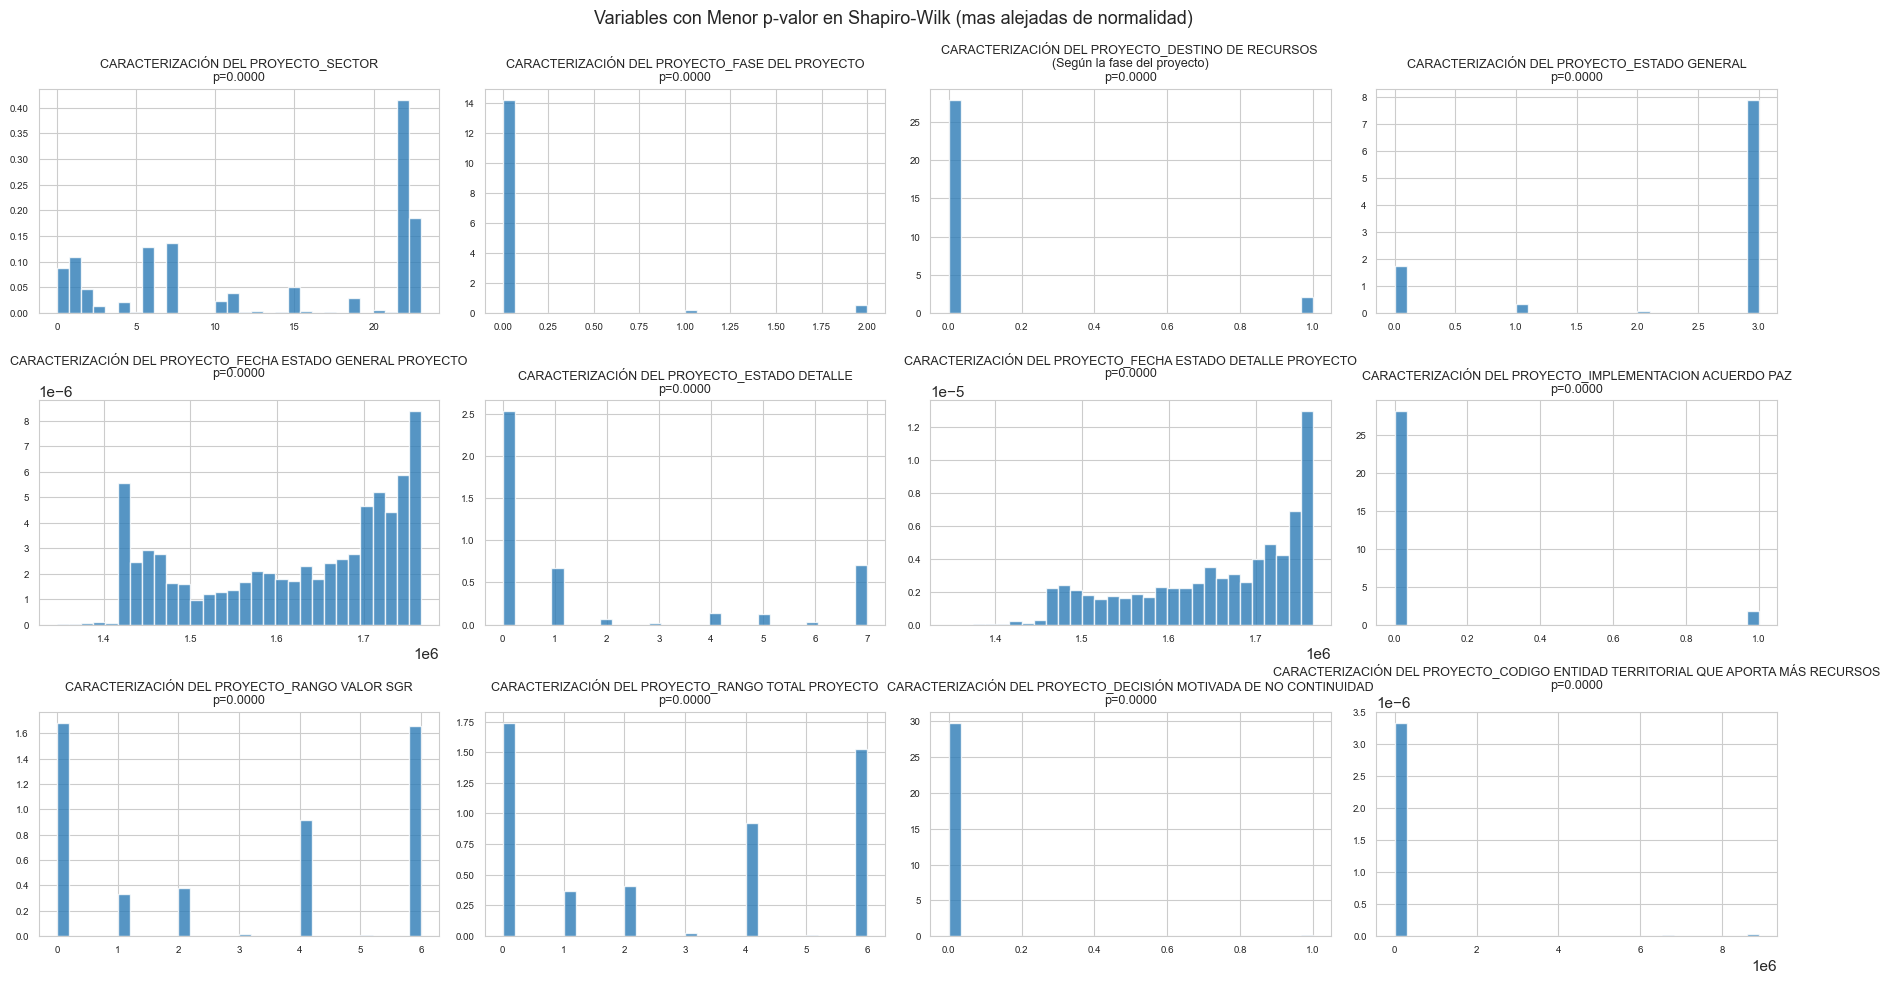

In [15]:
# =====================================================================
# FASE 2.6.1 : VISUALIZACION DE NORMALIDAD
# =====================================================================

# Histogramas de las 12 variables con menor p-valor (las mas no-normales)
peores = df_shapiro.dropna(subset=["p_valor"]).nsmallest(12, "p_valor")

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(peores.iterrows()):
    var = row["Variable"]
    ax = axes[idx]
    datos = df_num[var].dropna()
    ax.hist(datos, bins=30, color="#2c7bb6", edgecolor="white", alpha=0.8, density=True)
    ax.set_title(f"{var}\np={row['p_valor']:.4f}", fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle("Variables con Menor p-valor en Shapiro-Wilk (mas alejadas de normalidad)", fontsize=13)
plt.tight_layout()
plt.show()

# Fase 3 : Analisis de Correlacion y Multicolinealidad

## Fase 3.1 : Matriz de Correlación (Pearson y Spearman)

Se calculan **ambas matrices** de correlación:
- **Pearson:** captura asociaciones lineales (sensible a normalidad y outliers).
- **Spearman:** captura asociaciones monótonas basadas en rangos (robusta a
  no-normalidad y outliers).

Si los resultados de Shapiro-Wilk indicaron no-normalidad generalizada,
**Spearman es la métrica principal** para la detección de pares redundantes.
Se comparan ambas matrices para evaluar la robustez del análisis.

Metrica principal seleccionada: Spearman
  (Basado en que > 50% de variables rechazan normalidad)



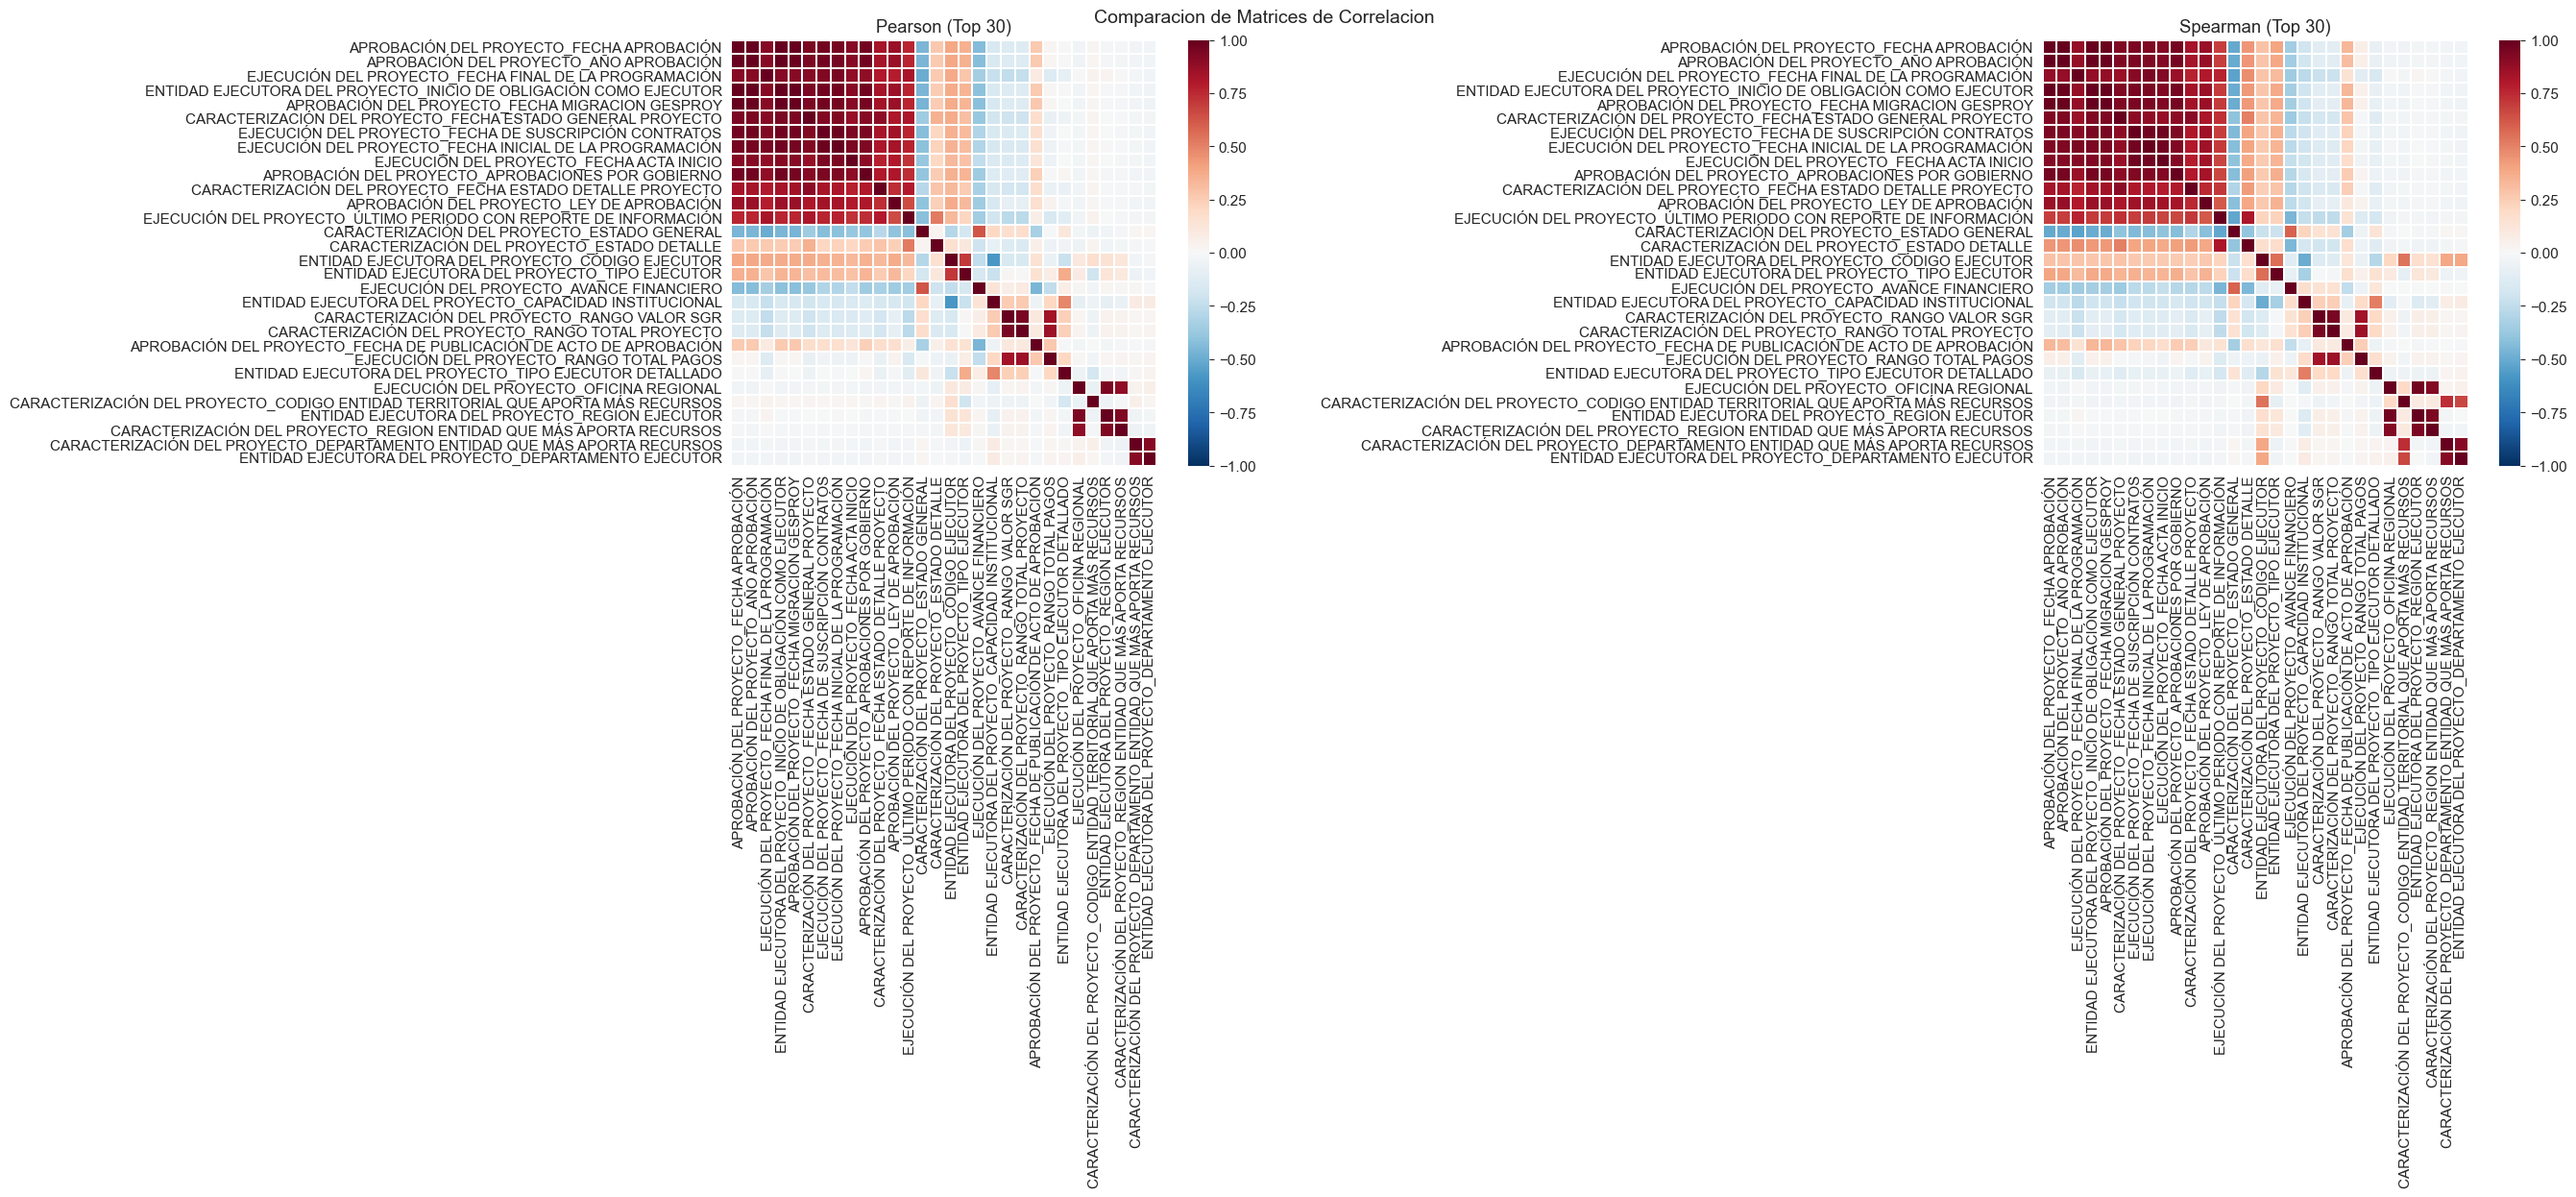

Diferencia media absoluta Pearson vs Spearman: 0.0283
Diferencia maxima: 0.6798
✅ Ambas matrices son consistentes. El analisis es robusto al metodo de correlacion.

Pares con |correlacion Spearman| > 0.85: 56
                                                       Variable_1                                                        Variable_2  Corr_Spearman
                  APROBACIÓN DEL PROYECTO_FECHA MIGRACION GESPROY ENTIDAD EJECUTORA DEL PROYECTO_INICIO DE OBLIGACIÓN COMO EJECUTOR         0.9970
                         APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN                            APROBACIÓN DEL PROYECTO_AÑO APROBACIÓN         0.9958
                         APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN ENTIDAD EJECUTORA DEL PROYECTO_INICIO DE OBLIGACIÓN COMO EJECUTOR         0.9924
                         APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN                   APROBACIÓN DEL PROYECTO_FECHA MIGRACION GESPROY         0.9910
                           APROBACIÓN DEL PROYECTO_AÑO A

In [16]:
# =====================================================================
# FASE 3.1 : CORRELACION PEARSON Y SPEARMAN
# =====================================================================

corr_pearson = df_num.corr(method="pearson")
corr_spearman = df_num.corr(method="spearman")

# Metrica principal segun normalidad
corr_matrix = corr_spearman if USAR_SPEARMAN else corr_pearson
metodo_principal = "Spearman" if USAR_SPEARMAN else "Pearson"
print(f"Metrica principal seleccionada: {metodo_principal}")
print(f"  (Basado en que {'>' if USAR_SPEARMAN else '<='} 50% de variables rechazan normalidad)\n")

# Top 30 variables por correlacion promedio absoluta
mean_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
n_mostrar = min(30, len(mean_abs_corr))
top_vars = mean_abs_corr.head(n_mostrar).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

sns.heatmap(corr_pearson.loc[top_vars, top_vars], annot=False, cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, square=True, ax=axes[0])
axes[0].set_title(f"Pearson (Top {n_mostrar})")

sns.heatmap(corr_spearman.loc[top_vars, top_vars], annot=False, cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, square=True, ax=axes[1])
axes[1].set_title(f"Spearman (Top {n_mostrar})")

plt.suptitle("Comparacion de Matrices de Correlacion", fontsize=14)
plt.tight_layout()
plt.show()

# Diferencia entre matrices para evaluar robustez
diff = (corr_pearson - corr_spearman).abs()
print(f"Diferencia media absoluta Pearson vs Spearman: {diff.mean().mean():.4f}")
print(f"Diferencia maxima: {diff.max().max():.4f}")
if diff.mean().mean() < 0.1:
    print("✅ Ambas matrices son consistentes. El analisis es robusto al metodo de correlacion.")
else:
    print("⚠️  Diferencias notables entre Pearson y Spearman. Usar Spearman como referencia principal.")

# Pares con correlacion alta (usando la metrica principal)
umbral_corr = 0.85
pares_alta_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > umbral_corr:
            pares_alta_corr.append({
                "Variable_1": corr_matrix.columns[i],
                "Variable_2": corr_matrix.columns[j],
                f"Corr_{metodo_principal}": round(corr_matrix.iloc[i, j], 4)
            })

df_pares = pd.DataFrame(pares_alta_corr)
if len(df_pares) > 0:
    df_pares = df_pares.sort_values(f"Corr_{metodo_principal}", key=abs, ascending=False)
print(f"\nPares con |correlacion {metodo_principal}| > {umbral_corr}: {len(df_pares)}")
if len(df_pares) > 0:
    print(df_pares.head(20).to_string(index=False))
else:
    print("No se encontraron pares con correlacion superior al umbral.")

## Fase 3.2 : Factor de Inflación de la Varianza (VIF)

El VIF cuantifica la multicolinealidad de cada variable respecto al resto. Para una variable $X_j$:

$$VIF_j = \frac{1}{1 - R_j^2}$$

donde $R_j^2$ es el coeficiente de determinación de la regresión de $X_j$ sobre todas las demás variables.

**Justificación del umbral VIF = 10:**
Un VIF superior a 10 indica que el 90% de la varianza de esa variable es explicable por las demás variables del conjunto, es decir, que la variable es estadísticamente redundante. Este umbral es el estándar en la literatura de econometría y análisis multivariante. En el contexto de selección no supervisada, la redundancia degrada la estabilidad del PCA y el Laplacian Score, puesto que variables altamente correlacionadas aportan el mismo "peso" múltiples veces al espacio latente.

El proceso es **iterativo**: en cada paso se elimina la variable con mayor VIF hasta que todas queden por debajo del umbral. Esto es preferible a eliminar todas simultáneamente, ya que al eliminar la variable más redundante el VIF del resto puede disminuir.

> Se estandarizan los datos antes del cálculo (StandardScaler) para garantizar estabilidad numérica en la inversión de matrices.


In [17]:
def calcular_vif_iterativo(df, umbral_vif=10, max_iteraciones=50):
    """
    Calcula VIF iterativamente, eliminando la variable con mayor VIF
    en cada paso hasta que todas queden bajo el umbral.

    Retorna
    -------
    pd.DataFrame  : VIF final
    list           : columnas eliminadas
    pd.DataFrame   : datos sin columnas multicolineales
    """
    df_vif = df.copy()
    eliminadas = []

    for iteracion in range(max_iteraciones):
        if df_vif.shape[1] < 2:
            print("Menos de 2 variables. Deteniendo.")
            break

        # Calcular VIF
        try:
            vif_data = pd.DataFrame({
                "Variable": df_vif.columns,
                "VIF": [
                    variance_inflation_factor(df_vif.values, i)
                    for i in range(df_vif.shape[1])
                ]
            }).sort_values("VIF", ascending=False)
        except Exception as e:
            print(f"Error calculando VIF: {e}")
            break

        max_vif = vif_data["VIF"].max()

        if max_vif <= umbral_vif or np.isinf(max_vif):
            if np.isinf(max_vif):
                # Eliminar variables con VIF infinito (perfecta colinealidad)
                vars_inf = vif_data[np.isinf(vif_data["VIF"])]["Variable"].tolist()
                for v in vars_inf[1:]:  # Mantener al menos una
                    eliminadas.append(v)
                    df_vif = df_vif.drop(columns=[v])
                    print(f"Iteracion {iteracion+1}: Eliminando '{v}' (VIF=inf)")
                continue
            print(f"Iteracion {iteracion+1}: Todas las variables con VIF <= {umbral_vif}. Fin.")
            break

        var_eliminar = vif_data.iloc[0]["Variable"]
        eliminadas.append(var_eliminar)
        print(f"Iteracion {iteracion+1}: Eliminando '{var_eliminar}' (VIF={max_vif:.2f})")
        df_vif = df_vif.drop(columns=[var_eliminar])

    # VIF final
    if df_vif.shape[1] >= 2:
        vif_final = pd.DataFrame({
            "Variable": df_vif.columns,
            "VIF": [
                variance_inflation_factor(df_vif.values, i)
                for i in range(df_vif.shape[1])
            ]
        }).sort_values("VIF", ascending=False)
    else:
        vif_final = pd.DataFrame({"Variable": df_vif.columns, "VIF": [1.0]*len(df_vif.columns)})

    return vif_final, eliminadas, df_vif


# Preparar datos
df_para_vif = df_num.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# Verificar que hay mas filas que columnas
if df_para_vif.shape[0] > df_para_vif.shape[1]:
    scaler_vif = StandardScaler()
    df_vif_scaled = pd.DataFrame(
        scaler_vif.fit_transform(df_para_vif),
        columns=df_para_vif.columns
    )
    print(f"Calculando VIF sobre {df_vif_scaled.shape[1]} variables...")
    print(f"Umbral VIF: {UMBRAL_VIF}\n")

    vif_resultado, cols_eliminadas_vif, df_post_vif = calcular_vif_iterativo(
        df_vif_scaled, umbral_vif=UMBRAL_VIF
    )
    print(f"\nVariables eliminadas por multicolinealidad: {len(cols_eliminadas_vif)}")
    print(f"Variables restantes tras VIF: {df_post_vif.shape[1]}")
    print("\nVIF final:")
    print(vif_resultado.to_string(index=False))
else:
    print(f"AVISO: El dataset tiene {df_para_vif.shape[0]} filas y {df_para_vif.shape[1]} columnas.")
    print("El VIF no es estable cuando n_filas <= n_columnas.")
    print("Se omite el filtro VIF. Usar la matriz de correlacion para detectar redundancia.")
    cols_eliminadas_vif = []
    df_post_vif = df_para_vif.copy()


Calculando VIF sobre 43 variables...
Umbral VIF: 10

Iteracion 1: Eliminando 'APROBACIÓN DEL PROYECTO_FECHA APROBACIÓN' (VIF=440.33)
Iteracion 2: Eliminando 'ENTIDAD EJECUTORA DEL PROYECTO_INICIO DE OBLIGACIÓN COMO EJECUTOR' (VIF=319.88)
Iteracion 3: Eliminando 'APROBACIÓN DEL PROYECTO_FECHA MIGRACION GESPROY' (VIF=90.30)
Iteracion 4: Eliminando 'APROBACIÓN DEL PROYECTO_AÑO APROBACIÓN' (VIF=51.72)
Iteracion 5: Eliminando 'EJECUCIÓN DEL PROYECTO_FECHA INICIAL DE LA PROGRAMACIÓN' (VIF=40.26)
Iteracion 6: Eliminando 'EJECUCIÓN DEL PROYECTO_FECHA DE SUSCRIPCIÓN CONTRATOS' (VIF=25.69)
Iteracion 7: Eliminando 'CARACTERIZACIÓN DEL PROYECTO_FECHA ESTADO GENERAL PROYECTO' (VIF=18.44)
Iteracion 8: Eliminando 'ENTIDAD EJECUTORA DEL PROYECTO_REGION EJECUTOR' (VIF=15.80)
Iteracion 9: Eliminando 'CARACTERIZACIÓN DEL PROYECTO_RANGO TOTAL PROYECTO' (VIF=13.52)
Iteracion 10: Eliminando 'EJECUCIÓN DEL PROYECTO_FECHA FINAL DE LA PROGRAMACIÓN' (VIF=11.03)
Iteracion 11: Todas las variables con VIF <= 10. F

### Nota Metodológica

El VIF (Factor de Inflación de la Varianza) cuantifica **exclusivamente
dependencias lineales** entre variables. Relaciones no lineales (cuadráticas,
exponenciales, interacciones complejas) **no son detectadas** por este indicador.

Dado el alcance exploratorio del presente análisis y que los métodos posteriores
(PCA, K-Means) también operan sobre supuestos de linealidad, esta limitación
es aceptable para el contexto actual. Un análisis más profundo requeriría
técnicas como HSIC (Hilbert-Schmidt Independence Criterion) o mutual
information para capturar dependencias no lineales.

# Fase 4 : Analisis Exploratorio No Supervisado

## Fase 4.0 : Preparacion del Dataset

Se construye la matriz estandarizada que alimentara PCA, clustering y los metodos
de seleccion de variables. Se utiliza StandardScaler (media=0, desviacion=1) que
es el preprocesamiento estandar para metodos basados en distancias y varianza.


In [18]:
# Usar columnas que pasaron el filtro VIF (o todas si VIF no se calculo)
columnas_analisis = [c for c in df_post_vif.columns if c in df_encoded.columns]
X = df_encoded[columnas_analisis].copy()

# Estandarizar
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"Matriz para analisis no supervisado:")
print(f"  Filas (observaciones): {X_scaled.shape[0]}")
print(f"  Columnas (variables):  {X_scaled.shape[1]}")


Matriz para analisis no supervisado:
  Filas (observaciones): 35388
  Columnas (variables):  33


## Fase 4.0.1 : Detección de Outliers Multivariados (Distancia de Mahalanobis)

Un outlier multivariado es una observación que es extrema en el **espacio
combinado** de variables, aunque puede no ser extrema en ninguna variable
individual. En PCA, estos outliers jalan los componentes principales hacia
sí mismos, distorsionando los loadings de **todas** las variables.

Se calcula la distancia de Mahalanobis de cada observación y se compara contra
el cuantil chi-cuadrado con p grados de libertad (p = número de variables).
Las observaciones cuya distancia supere el percentil 97.5 se marcan como
outliers multivariados.

DETECCION DE OUTLIERS MULTIVARIADOS — DISTANCIA DE MAHALANOBIS
Observaciones totales:      35388
Variables en el espacio:    33
Umbral chi2(0.975, 33):   7.1222
Outliers detectados:        4479 (12.7%)

Indices de outliers: [6, 7, 8, 9, 10, 11, 12, 17, 18, 19, 21, 23, 25, 30, 31, 32, 33, 36, 37, 38]...


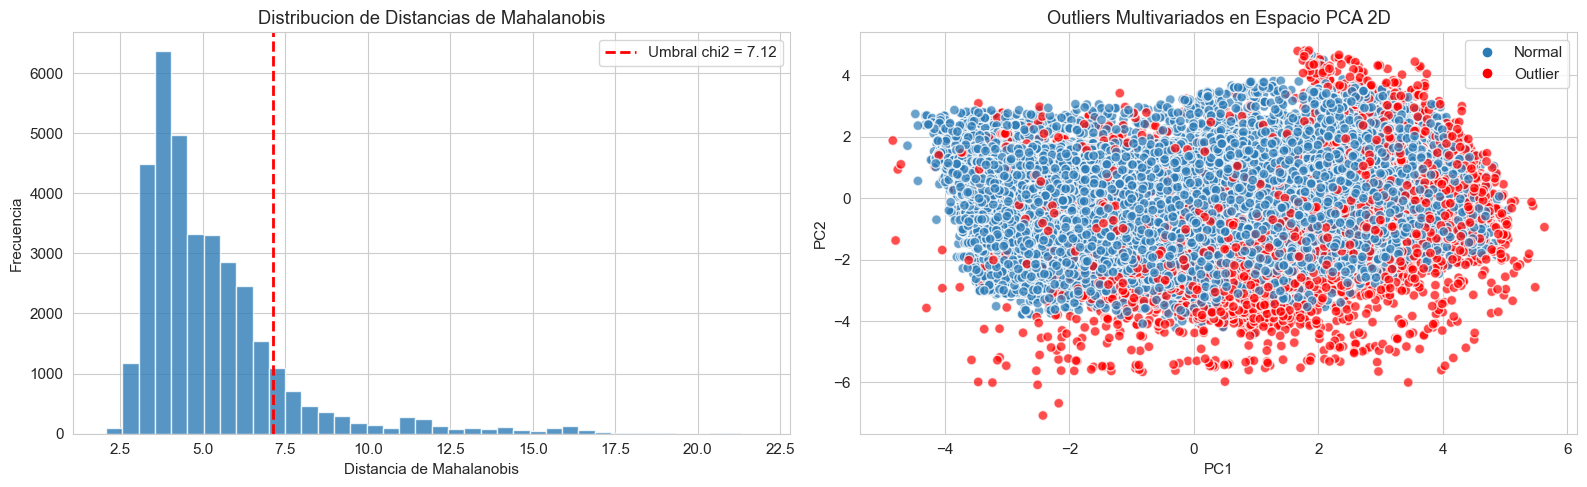


💡 RECOMENDACION: ejecutar PCA con y sin outliers para evaluar su impacto en loadings.


In [19]:
# =====================================================================
# FASE 4.0.1 : DETECCION DE OUTLIERS MULTIVARIADOS — MAHALANOBIS
# =====================================================================
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

X_mah = X_scaled.values  # datos ya estandarizados
n_obs, n_vars = X_mah.shape

# Matriz de covarianza y su inversa (con regularizacion por estabilidad)
cov_matrix = np.cov(X_mah, rowvar=False)
# Regularizar si la matriz es singular o casi-singular
try:
    cov_inv = np.linalg.inv(cov_matrix)
except np.linalg.LinAlgError:
    print("⚠️  Matriz de covarianza singular. Aplicando regularizacion (shrinkage).")
    from sklearn.covariance import LedoitWolf
    lw = LedoitWolf().fit(X_mah)
    cov_inv = np.linalg.inv(lw.covariance_)

media = X_mah.mean(axis=0)

# Calcular distancia de Mahalanobis para cada observacion
distancias_mah = np.array([
    mahalanobis(X_mah[i], media, cov_inv) for i in range(n_obs)
])

# Umbral: percentil 97.5 de la distribucion chi-cuadrado con p grados de libertad
umbral_chi2 = chi2.ppf(0.975, df=n_vars)

# Identificar outliers
es_outlier = distancias_mah > np.sqrt(umbral_chi2)
n_outliers = es_outlier.sum()
idx_outliers = np.where(es_outlier)[0]

print("=" * 70)
print("DETECCION DE OUTLIERS MULTIVARIADOS — DISTANCIA DE MAHALANOBIS")
print("=" * 70)
print(f"Observaciones totales:      {n_obs}")
print(f"Variables en el espacio:    {n_vars}")
print(f"Umbral chi2(0.975, {n_vars}):   {np.sqrt(umbral_chi2):.4f}")
print(f"Outliers detectados:        {n_outliers} ({n_outliers/n_obs*100:.1f}%)")

if n_outliers > 0:
    print(f"\nIndices de outliers: {idx_outliers[:20].tolist()}{'...' if n_outliers > 20 else ''}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribucion de distancias
axes[0].hist(distancias_mah, bins=40, color="#2c7bb6", edgecolor="white", alpha=0.8)
axes[0].axvline(np.sqrt(umbral_chi2), color="red", linestyle="--", linewidth=2,
                label=f"Umbral chi2 = {np.sqrt(umbral_chi2):.2f}")
axes[0].set_xlabel("Distancia de Mahalanobis")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribucion de Distancias de Mahalanobis")
axes[0].legend()

# Scatter con outliers marcados
if X_scaled.shape[1] >= 2:
    pca_temp = PCA(n_components=2, random_state=42)
    X_2d = pca_temp.fit_transform(X_scaled)
    colores = ["red" if o else "#2c7bb6" for o in es_outlier]
    axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=colores, s=50, alpha=0.7, edgecolor="white")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].set_title("Outliers Multivariados en Espacio PCA 2D")
    # Leyenda manual
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#2c7bb6', markersize=8, label='Normal'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Outlier')]
    axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# Guardar para comparacion posterior
outlier_mask = es_outlier.copy()
print(f"\n💡 RECOMENDACION: ejecutar PCA con y sin outliers para evaluar su impacto en loadings.")

In [20]:
# =====================================================================
# FASE 4.0.1b : COMPARACION PCA CON Y SIN OUTLIERS
# =====================================================================

if n_outliers > 0 and n_outliers < n_obs * 0.3:  # Solo si hay outliers y no son demasiados
    # PCA sin outliers
    X_sin_outliers = X_scaled[~es_outlier]
    pca_sin = PCA(n_components=min(5, X_sin_outliers.shape[1]), random_state=42)
    pca_sin.fit(X_sin_outliers)

    # PCA con todos
    pca_con = PCA(n_components=min(5, X_scaled.shape[1]), random_state=42)
    pca_con.fit(X_scaled)

    # Comparar varianza explicada
    print("COMPARACION DE VARIANZA EXPLICADA (primeros 5 componentes):")
    print(f"{'Componente':<15} {'Con outliers':>15} {'Sin outliers':>15} {'Diferencia':>12}")
    print("-" * 60)
    for i in range(min(5, len(pca_con.explained_variance_ratio_))):
        v_con = pca_con.explained_variance_ratio_[i] * 100
        v_sin = pca_sin.explained_variance_ratio_[i] * 100
        print(f"  PC{i+1:<12} {v_con:>14.2f}% {v_sin:>14.2f}% {v_con - v_sin:>+11.2f}%")

    # Comparar loadings del PC1
    loadings_con = pd.Series(pca_con.components_[0], index=X_scaled.columns).abs().sort_values(ascending=False)
    loadings_sin = pd.Series(pca_sin.components_[0], index=X_sin_outliers.columns).abs().sort_values(ascending=False)

    print(f"\nTop 10 variables por |loading| en PC1:")
    print(f"{'Con outliers':<40} {'Sin outliers':<40}")
    print("-" * 80)
    for i in range(min(10, len(loadings_con))):
        v_con = f"{loadings_con.index[i]} ({loadings_con.iloc[i]:.4f})"
        v_sin = f"{loadings_sin.index[i]} ({loadings_sin.iloc[i]:.4f})" if i < len(loadings_sin) else ""
        print(f"{v_con:<40} {v_sin:<40}")

    print("\n✅ Si el ranking de variables es similar, los outliers no distorsionan significativamente el PCA.")
    print("⚠️  Si difiere mucho, considerar excluir outliers o usar Robust PCA.")
else:
    if n_outliers == 0:
        print("✅ No se detectaron outliers multivariados. No es necesaria la comparacion.")
    else:
        print(f"⚠️  Demasiados outliers ({n_outliers}/{n_obs}). Revisar la calidad de los datos.")

COMPARACION DE VARIANZA EXPLICADA (primeros 5 componentes):
Componente         Con outliers    Sin outliers   Diferencia
------------------------------------------------------------
  PC1                     16.16%          21.44%       -5.27%
  PC2                      7.39%           9.39%       -2.00%
  PC3                      6.46%           8.62%       -2.16%
  PC4                      5.90%           8.03%       -2.12%
  PC5                      5.67%           6.37%       -0.69%

Top 10 variables por |loading| en PC1:
Con outliers                             Sin outliers                            
--------------------------------------------------------------------------------
APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO (0.3792) APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO (0.3971)
EJECUCIÓN DEL PROYECTO_FECHA ACTA INICIO (0.3683) EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN (0.3936)
EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓ


## Fase 4.0.2 : Validación de Supuestos para PCA

Antes de ejecutar PCA, se verifican dos condiciones necesarias:

### Test de Esfericidad de Bartlett
Prueba si la matriz de correlación es significativamente diferente de una
matriz identidad. Si **no** se puede rechazar H₀, las variables no están
correlacionadas y PCA no tiene estructura que comprimir.

**Criterio:** p < 0.05 para proceder con PCA.

### Kaiser-Meyer-Olkin (KMO)
Mide la proporción de varianza entre variables que podría ser varianza común
(compartida). Un KMO bajo indica que las correlaciones parciales son grandes
respecto a las simples, y PCA no capturará bien la estructura.

**Criterio:**
- KMO ≥ 0.9: Excelente
- KMO ≥ 0.8: Bueno
- KMO ≥ 0.6: Aceptable
- KMO < 0.6: Inaceptable (PCA no recomendado)

In [21]:
# =====================================================================
# FASE 4.0.2 : BARTLETT Y KMO — VALIDACION DE SUPUESTOS PARA PCA
# =====================================================================

# --- Test de Esfericidad de Bartlett ---
from scipy.stats import chi2 as chi2_dist

corr = X_scaled.corr().values.copy()  # .copy() evita error read-only
n = X_scaled.shape[0]
p = X_scaled.shape[1]

det_corr = np.linalg.det(corr)
if det_corr <= 0:
    bartlett_stat = np.inf
    bartlett_p = 0.0
    print("⚠️  Determinante de la matriz de correlacion <= 0 (singular).")
    print("   Esto implica colinealidad perfecta; Bartlett rechaza H0 trivialmente.")
else:
    bartlett_stat = -((n - 1) - (2 * p + 5) / 6) * np.log(det_corr)
    bartlett_df = p * (p - 1) / 2
    bartlett_p = 1 - chi2_dist.cdf(bartlett_stat, bartlett_df)

print("=" * 70)
print("TEST DE ESFERICIDAD DE BARTLETT")
print("=" * 70)
print(f"  Estadistico chi2:  {bartlett_stat:.2f}")
print(f"  Grados de libertad: {p * (p - 1) / 2:.0f}")
print(f"  p-valor:           {bartlett_p:.6e}")
if bartlett_p < 0.05:
    print("  ✅ Se rechaza H0: la matriz de correlacion NO es identidad.")
    print("     Las variables estan correlacionadas. PCA es apropiado.")
else:
    print("  ❌ NO se rechaza H0: las variables no estan correlacionadas.")
    print("     PCA no es recomendable con estos datos.")

# --- Kaiser-Meyer-Olkin (KMO) ---
from numpy.linalg import inv

corr_matrix_kmo = X_scaled.corr().values.copy()  # .copy() evita error read-only

try:
    corr_inv_kmo = inv(corr_matrix_kmo)
except np.linalg.LinAlgError:
    print("\n⚠️  Matriz singular. Aplicando regularizacion.")
    corr_matrix_kmo += np.eye(p) * 1e-8
    corr_inv_kmo = inv(corr_matrix_kmo)

try:
    diag = np.diag(corr_inv_kmo).copy()
    diag = np.where(diag <= 0, 1e-10, diag)
    parciales = -corr_inv_kmo / np.sqrt(np.outer(diag, diag))

    # Copias mutables para fill_diagonal
    parciales_z = parciales.copy()
    np.fill_diagonal(parciales_z, 0)

    corr_kmo_z = corr_matrix_kmo.copy()
    np.fill_diagonal(corr_kmo_z, 0)

    sum_r2 = (corr_kmo_z ** 2).sum()
    sum_a2 = (parciales_z ** 2).sum()
    kmo_global = sum_r2 / (sum_r2 + sum_a2)

    # KMO por variable
    kmo_por_var = []
    for j in range(p):
        mask = np.ones(p, dtype=bool)
        mask[j] = False
        r2_j = (corr_kmo_z[j, mask] ** 2).sum()
        a2_j = (parciales_z[j, mask] ** 2).sum()
        kmo_j = r2_j / (r2_j + a2_j) if (r2_j + a2_j) > 0 else 0
        kmo_por_var.append(kmo_j)

    kmo_por_var = pd.Series(kmo_por_var, index=X_scaled.columns)

    print("\n" + "=" * 70)
    print("KAISER-MEYER-OLKIN (KMO)")
    print("=" * 70)
    print(f"  KMO global: {kmo_global:.4f}")

    if kmo_global >= 0.9:
        print("  ✅ Excelente adecuacion muestral para PCA.")
    elif kmo_global >= 0.8:
        print("  ✅ Buena adecuacion muestral para PCA.")
    elif kmo_global >= 0.6:
        print("  ⚠️  Adecuacion aceptable. PCA procede con cautela.")
    else:
        print("  ❌ Adecuacion inaceptable (KMO < 0.6). PCA NO recomendado.")

    kmo_sorted = kmo_por_var.sort_values()
    print(f"\n  Variables con menor KMO individual (considerar excluir si < 0.5):")
    for var, val in kmo_sorted.head(10).items():
        flag = " ❌" if val < 0.5 else ""
        print(f"    {var}: {val:.4f}{flag}")

except Exception as e:
    print(f"\n⚠️  Error calculando KMO: {e}")
    print("   Revisar el filtro VIF o eliminar variables redundantes.")
    kmo_global = None


TEST DE ESFERICIDAD DE BARTLETT
  Estadistico chi2:  601708.19
  Grados de libertad: 528
  p-valor:           0.000000e+00
  ✅ Se rechaza H0: la matriz de correlacion NO es identidad.
     Las variables estan correlacionadas. PCA es apropiado.

KAISER-MEYER-OLKIN (KMO)
  KMO global: 0.6436
  ⚠️  Adecuacion aceptable. PCA procede con cautela.

  Variables con menor KMO individual (considerar excluir si < 0.5):
    CARACTERIZACIÓN DEL PROYECTO_CODIGO ENTIDAD TERRITORIAL QUE APORTA MÁS RECURSOS: 0.2647 ❌
    ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR DETALLADO: 0.3685 ❌
    ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR: 0.4480 ❌
    CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE: 0.4518 ❌
    CARACTERIZACIÓN DEL PROYECTO_DECISIÓN MOTIVADA DE NO CONTINUIDAD: 0.4640 ❌
    ENTIDAD EJECUTORA DEL PROYECTO_DIGITO VERIFICACIÓN: 0.4743 ❌
    CARACTERIZACIÓN DEL PROYECTO_IMPLEMENTACION ACUERDO PAZ: 0.4828 ❌
    ENTIDAD EJECUTORA DEL PROYECTO_DEPARTAMENTO EJECUTOR: 0.4842 ❌
    CARACTERIZACIÓN DEL PR

## Fase 4.1 : Análisis de Componentes Principales (Exploratorio)

En esta fase, el PCA se usa **exclusivamente con fines exploratorios y de visualización**, no como método de selección. Su propósito es:

1. Cuantificar la varianza explicada acumulada para entender la compresibilidad del dataset.
2. Identificar el número mínimo de dimensiones que concentran la información.
3. Calcular los **loadings** (pesos de variables originales en cada componente) que se usan posteriormente en la Fase 5 como criterio de selección.

**Fundamento del PCA:**
El PCA proyecta los datos a un espacio ortogonal donde los ejes (componentes) están ordenados por varianza explicada decreciente. El componente $k$-ésimo es la dirección $\mathbf{w}_k$ que maximiza $Var(\mathbf{X}\mathbf{w}_k)$ sujeto a ortogonalidad con los componentes anteriores. Los **loadings** $a_{jk}$ representan la contribución de la variable $X_j$ al componente $k$.

> Jolliffe, I. T. (2002). *Principal Component Analysis* (2.ª ed.). Springer Series in Statistics. — Capítulo 6: "Choosing a Subset of Principal Components or Variables".

**Nota:** El PCA se aplica sobre datos estandarizados (media 0, desviación estándar 1) para garantizar que todas las variables contribuyan equitativamente, independientemente de su escala original.


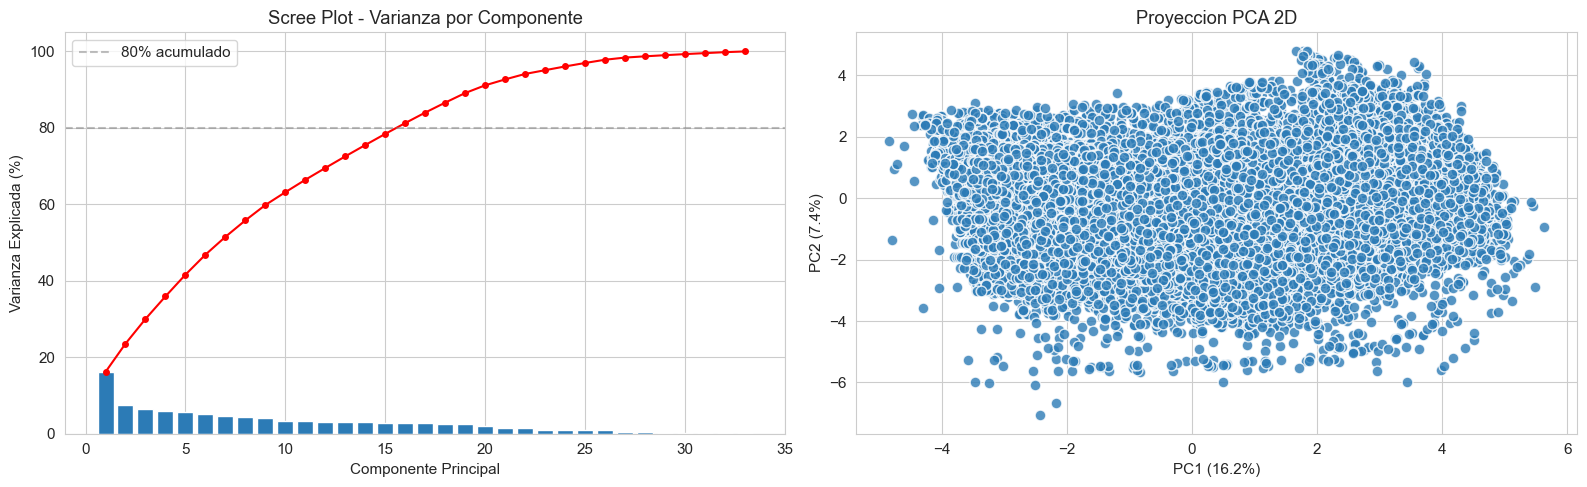

Componentes para explicar el 80% de la varianza: 16 de 33
Varianza explicada por PC1: 16.16%
Varianza explicada por PC1+PC2: 23.56%


In [22]:
# Calcular PCA con todos los componentes posibles
n_componentes = min(X_scaled.shape[0], X_scaled.shape[1])
pca = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza_acum = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100, color="#2c7bb6", edgecolor="white")
axes[0].plot(range(1, len(varianza_acum) + 1), varianza_acum, "r-o", markersize=4)
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza Explicada (%)")
axes[0].set_title("Scree Plot - Varianza por Componente")
axes[0].axhline(y=80, color="gray", linestyle="--", alpha=0.5, label="80% acumulado")
axes[0].legend()

# Proyeccion 2D
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c="#2c7bb6", s=60, edgecolor="white", alpha=0.8)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Proyeccion PCA 2D")

plt.tight_layout()
plt.show()

# Componentes necesarios para 80% de varianza
n_80 = np.argmax(varianza_acum >= 80) + 1
print(f"Componentes para explicar el 80% de la varianza: {n_80} de {n_componentes}")
print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada por PC1+PC2: {varianza_acum[1]:.2f}%")


## Fase 4.1.1 : Analisis de Loadings PCA

Los loadings representan la correlacion entre cada variable original y cada
componente principal. Una variable con loadings altos (en valor absoluto) en los
primeros componentes es una variable que captura una proporcion significativa de
la varianza total del dataset.

Se calcula la "importancia PCA" de cada variable como la suma ponderada de sus
loadings absolutos por la varianza explicada de cada componente.


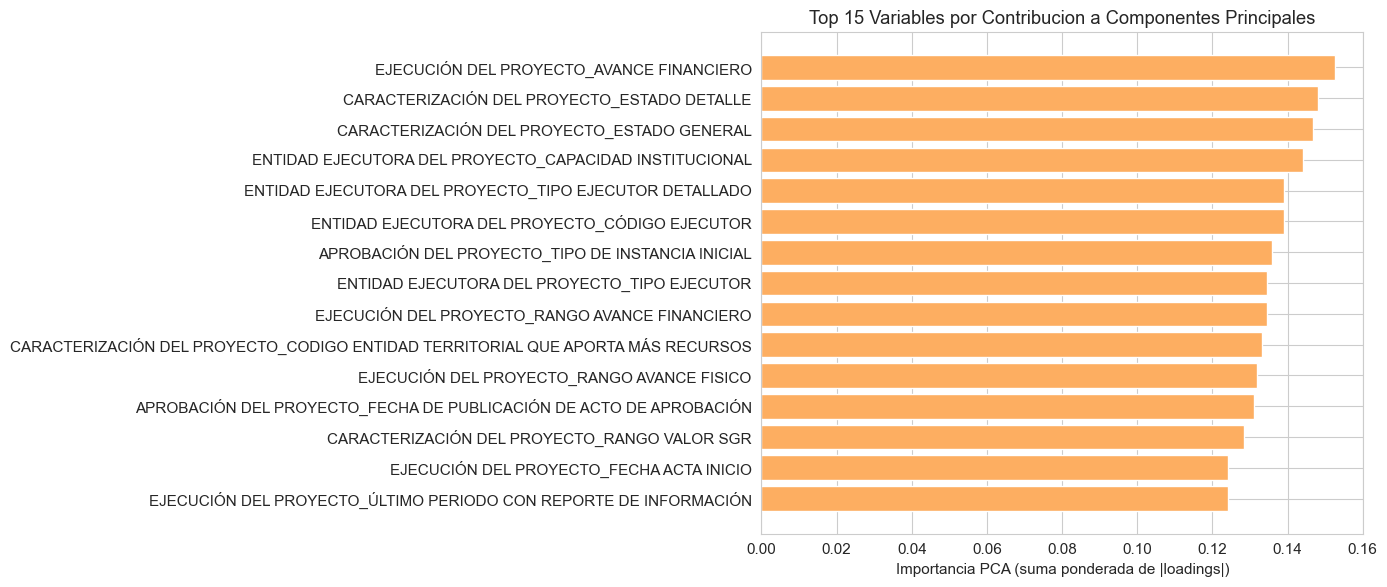

Top 15 variables por importancia PCA:
  EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO: 0.152566
  CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE: 0.148040
  CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL: 0.146658
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: 0.144078
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR DETALLADO: 0.139089
  ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR: 0.138999
  APROBACIÓN DEL PROYECTO_TIPO DE INSTANCIA INICIAL: 0.135756
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR: 0.134601
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FINANCIERO: 0.134486
  CARACTERIZACIÓN DEL PROYECTO_CODIGO ENTIDAD TERRITORIAL QUE APORTA MÁS RECURSOS: 0.133342
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FISICO: 0.131866
  APROBACIÓN DEL PROYECTO_FECHA DE PUBLICACIÓN DE ACTO DE APROBACIÓN: 0.131211
  CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR: 0.128432
  EJECUCIÓN DEL PROYECTO_FECHA ACTA INICIO: 0.124253
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN: 0.124121


In [23]:
# Matriz de loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(n_componentes)],
    index=X.columns
)

# Importancia PCA: suma ponderada de |loading| x varianza_explicada
importancia_pca = (loadings.abs() * pca.explained_variance_ratio_).sum(axis=1)
importancia_pca = importancia_pca.sort_values(ascending=False)

# Visualizacion de loadings PC1 vs PC2
fig, ax = plt.subplots(figsize=(14, max(6, min(TOP_N, len(importancia_pca)) * 0.4)))
top_pca = importancia_pca.head(TOP_N)
ax.barh(
    top_pca.index[::-1],
    top_pca.values[::-1],
    color="#fdae61", edgecolor="white"
)
ax.set_xlabel("Importancia PCA (suma ponderada de |loadings|)")
ax.set_title(f"Top {min(TOP_N, len(top_pca))} Variables por Contribucion a Componentes Principales")
plt.tight_layout()
plt.show()

print(f"Top {min(TOP_N, len(top_pca))} variables por importancia PCA:")
for var, val in top_pca.items():
    print(f"  {var}: {val:.6f}")


## Fase 4.1.0 : Análisis Paralelo (Horn, 1965) para Selección de Componentes

El scree plot y el criterio de varianza acumulada son heurísticos visuales.
El **Análisis Paralelo** es un método más riguroso: genera matrices aleatorias
del mismo tamaño (n × p), calcula sus eigenvalues, y retiene solo los
componentes cuyo eigenvalue real supera el **percentil 95** de los aleatorios.
Esto evita retener componentes que explican varianza por azar.


ANALISIS PARALELO (Horn, 1965)
Simulaciones: 1000
Componentes a retener (eigenvalue real > P95 aleatorio): 12

Componente         Eigenvalue Real      P95 Aleatorio   Retener?
-----------------------------------------------------------------
  PC1                       5.3344            1.0623        Si  ✅
  PC2                       2.4392            1.0545        Si  ✅
  PC3                       2.1312            1.0487        Si  ✅
  PC4                       1.9486            1.0446        Si  ✅
  PC5                       1.8722            1.0401        Si  ✅
  PC6                       1.7270            1.0365        Si  ✅
  PC7                       1.5386            1.0328        Si  ✅
  PC8                       1.4224            1.0298        Si  ✅
  PC9                       1.3255            1.0261        Si  ✅
  PC10                      1.1057            1.0230        Si  ✅
  PC11                      1.0709            1.0199        Si  ✅
  PC12                      1.01

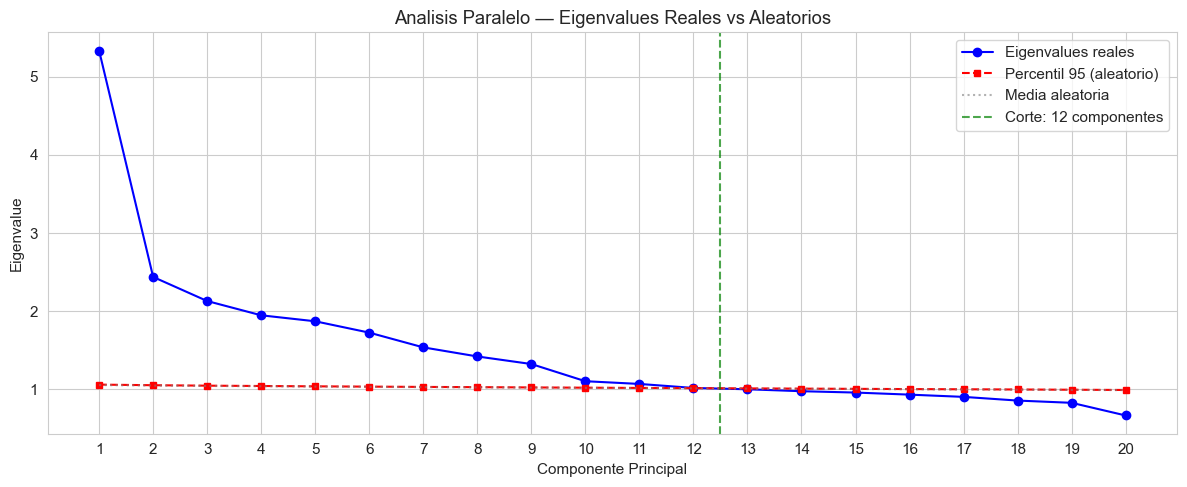


📌 RESUMEN DE CRITERIOS PARA NUMERO DE COMPONENTES:
   Criterio de varianza acumulada >=80%: 16 componentes
   Analisis Paralelo (Horn):             12 componentes


In [24]:
# =====================================================================
# FASE 4.1.0 : ANALISIS PARALELO (HORN, 1965)
# =====================================================================

n_simulaciones = 1000
n_obs_pa, n_vars_pa = X_scaled.shape

# Eigenvalues reales (de la matriz de correlacion)
corr_real = X_scaled.corr().values.copy()
eigenvalues_corr = np.sort(np.linalg.eigvalsh(corr_real))[::-1]

# Simular matrices aleatorias
eigenvalues_aleatorios = np.zeros((n_simulaciones, n_vars_pa))

np.random.seed(RANDOM_STATE)
for sim in range(n_simulaciones):
    datos_random = np.random.normal(0, 1, size=(n_obs_pa, n_vars_pa))
    corr_random = np.corrcoef(datos_random, rowvar=False)
    eigenvalues_aleatorios[sim, :] = np.sort(np.linalg.eigvalsh(corr_random))[::-1]

eigen_p95 = np.percentile(eigenvalues_aleatorios, 95, axis=0)
eigen_media = eigenvalues_aleatorios.mean(axis=0)

# Componentes a retener
n_retener_pa = 0
for i in range(len(eigenvalues_corr)):
    if eigenvalues_corr[i] > eigen_p95[i]:
        n_retener_pa += 1
    else:
        break

print("=" * 70)
print("ANALISIS PARALELO (Horn, 1965)")
print("=" * 70)
print(f"Simulaciones: {n_simulaciones}")
print(f"Componentes a retener (eigenvalue real > P95 aleatorio): {n_retener_pa}")
print(f"\n{'Componente':<15} {'Eigenvalue Real':>18} {'P95 Aleatorio':>18} {'Retener?':>10}")
print("-" * 65)
for i in range(min(15, len(eigenvalues_corr))):
    retener = "Si" if eigenvalues_corr[i] > eigen_p95[i] else "No"
    marca = "  ✅" if retener == "Si" else "  ·"
    print(f"  PC{i+1:<12} {eigenvalues_corr[i]:>17.4f} {eigen_p95[i]:>17.4f} {retener:>9}{marca}")

# Grafico comparativo
fig, ax = plt.subplots(figsize=(12, 5))
x_range = range(1, min(20, len(eigenvalues_corr)) + 1)
ax.plot(x_range, eigenvalues_corr[:len(x_range)], "b-o", markersize=6, label="Eigenvalues reales")
ax.plot(x_range, eigen_p95[:len(x_range)], "r--s", markersize=5, label="Percentil 95 (aleatorio)")
ax.plot(x_range, eigen_media[:len(x_range)], "gray", linestyle=":", alpha=0.6, label="Media aleatoria")
ax.axvline(n_retener_pa + 0.5, color="green", linestyle="--", alpha=0.7,
           label=f"Corte: {n_retener_pa} componentes")
ax.set_xlabel("Componente Principal")
ax.set_ylabel("Eigenvalue")
ax.set_title("Analisis Paralelo — Eigenvalues Reales vs Aleatorios")
ax.legend()
ax.set_xticks(list(x_range))
plt.tight_layout()
plt.show()

print(f"\n📌 RESUMEN DE CRITERIOS PARA NUMERO DE COMPONENTES:")
print(f"   Criterio de varianza acumulada >=80%: {n_80} componentes")
print(f"   Analisis Paralelo (Horn):             {n_retener_pa} componentes")


## Fase 4.2 : Clustering Jerarquico

El dendrograma permite visualizar la estructura de agrupamiento natural de los
proyectos sin asumir un numero predefinido de clusters. Se utiliza el metodo
de Ward, que minimiza la varianza intra-cluster, y la distancia euclidiana
sobre los datos estandarizados.


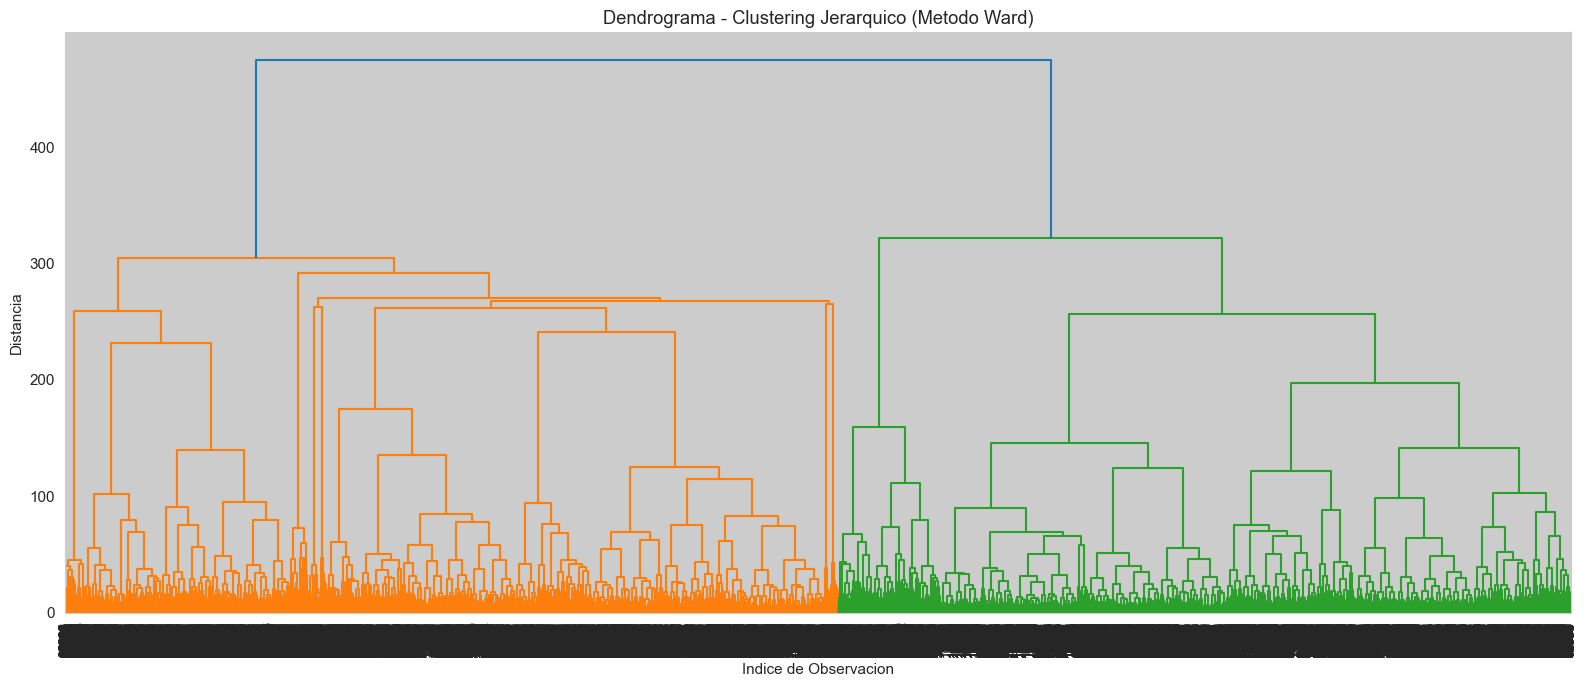

In [25]:
# Dendrograma
if X_scaled.shape[0] >= 3:
    Z = linkage(X_scaled, method="ward", metric="euclidean")

    fig, ax = plt.subplots(figsize=(16, 7))
    dendrogram(
        Z,
        leaf_rotation=90,
        leaf_font_size=9,
        color_threshold=0.7 * max(Z[:, 2]),
        ax=ax
    )
    ax.set_title("Dendrograma - Clustering Jerarquico (Metodo Ward)")
    ax.set_xlabel("Indice de Observacion")
    ax.set_ylabel("Distancia")
    plt.tight_layout()
    plt.show()
else:
    print("Se requieren al menos 3 observaciones para el dendrograma.")


## Fase 4.2.1 : Coeficiente de Correlación Cofenética

El coeficiente cofenético mide qué tan fielmente el dendrograma preserva las
distancias originales entre pares de observaciones. Un valor alto (> 0.7)
indica que la representación jerárquica es una buena aproximación de la
estructura real de distancias en los datos.


In [26]:
# =====================================================================
# FASE 4.2.1 : COEFICIENTE COFENETICO
# =====================================================================
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

if X_scaled.shape[0] >= 3:
    dist_original = pdist(X_scaled, metric="euclidean")
    c_coef, dist_cofenetica = cophenet(Z, dist_original)

    print("=" * 70)
    print("COEFICIENTE DE CORRELACION COFENETICA")
    print("=" * 70)
    print(f"  Coeficiente cofenetico: {c_coef:.4f}")

    if c_coef >= 0.8:
        print("  ✅ Excelente representacion. El dendrograma preserva bien las distancias reales.")
    elif c_coef >= 0.7:
        print("  ✅ Buena representacion. Estructura jerarquica razonable.")
    elif c_coef >= 0.5:
        print("  ⚠️  Representacion moderada. El dendrograma simplifica en exceso algunas relaciones.")
    else:
        print("  ❌ Representacion pobre. Considerar otros metodos de enlace (complete, average).")
else:
    print("Se requieren al menos 3 observaciones.")


COEFICIENTE DE CORRELACION COFENETICA
  Coeficiente cofenetico: 0.3120
  ❌ Representacion pobre. Considerar otros metodos de enlace (complete, average).


## Fase 4.3.0 : Test de Hopkins (Tendencia al Agrupamiento)

Antes de aplicar K-Means, se verifica si los datos tienen **estructura de
clustering** o si son esencialmente uniformes (donde cualquier partición sería
artificial).

El estadístico de Hopkins compara las distancias de puntos aleatorios a sus
vecinos más cercanos en el dataset real vs. en un dataset uniforme.

**Criterio:**
- H ≈ 0.5: datos uniformes (sin estructura de clusters).
- H > 0.7: tendencia moderada al agrupamiento.
- H > 0.75: buena tendencia al agrupamiento.


In [27]:
# =====================================================================
# FASE 4.3.0 : TEST DE HOPKINS
# =====================================================================
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, n_sample=None, random_state=42):
    """
    Calcula el estadistico de Hopkins para evaluar la tendencia
    al agrupamiento de un dataset.
    """
    np.random.seed(random_state)
    X_arr = np.array(X)
    n, d = X_arr.shape

    if n_sample is None:
        n_sample = min(max(int(n * 0.1), 10), n - 1)

    idx = np.random.choice(n, n_sample, replace=False)
    X_muestra = X_arr[idx]

    X_min = X_arr.min(axis=0)
    X_max = X_arr.max(axis=0)
    X_uniform = np.random.uniform(X_min, X_max, size=(n_sample, d))

    nn = NearestNeighbors(n_neighbors=2).fit(X_arr)

    dist_real, _ = nn.kneighbors(X_muestra)
    w = dist_real[:, 1]

    dist_uniform, _ = nn.kneighbors(X_uniform)
    u = dist_uniform[:, 1]

    H = u.sum() / (u.sum() + w.sum())
    return H

# Calcular Hopkins (repetir varias veces para estabilidad)
n_repeticiones = 50
hopkins_values = [
    hopkins_statistic(X_scaled.values, random_state=42 + i)
    for i in range(n_repeticiones)
]
hopkins_mean = np.mean(hopkins_values)
hopkins_std = np.std(hopkins_values)

print("=" * 70)
print("TEST DE HOPKINS — TENDENCIA AL AGRUPAMIENTO")
print("=" * 70)
print(f"  Hopkins medio ({n_repeticiones} repeticiones): {hopkins_mean:.4f} ± {hopkins_std:.4f}")

if hopkins_mean > 0.75:
    print("  ✅ Buena tendencia al agrupamiento. K-Means es pertinente.")
elif hopkins_mean > 0.7:
    print("  ✅ Tendencia moderada al agrupamiento. K-Means puede aplicarse.")
elif hopkins_mean > 0.55:
    print("  ⚠️  Tendencia debil al agrupamiento. Interpretar clusters con cautela.")
else:
    print("  ❌ Los datos parecen uniformes. K-Means producira particiones artificiales.")
    print("     Considerar si el clustering agrega valor al analisis.")


TEST DE HOPKINS — TENDENCIA AL AGRUPAMIENTO
  Hopkins medio (50 repeticiones): 0.9352 ± 0.0008
  ✅ Buena tendencia al agrupamiento. K-Means es pertinente.


## Fase 4.3 : K-Means con Analisis de Silueta

Se evaluan multiples valores de K para identificar el numero optimo de clusters
mediante el coeficiente de silueta (rango [-1, 1]; valores mas altos indican
clusters mejor definidos) y el metodo del codo (inercia).

El coeficiente de silueta mide que tan similar es cada observacion a su propio
cluster comparado con el cluster mas cercano.


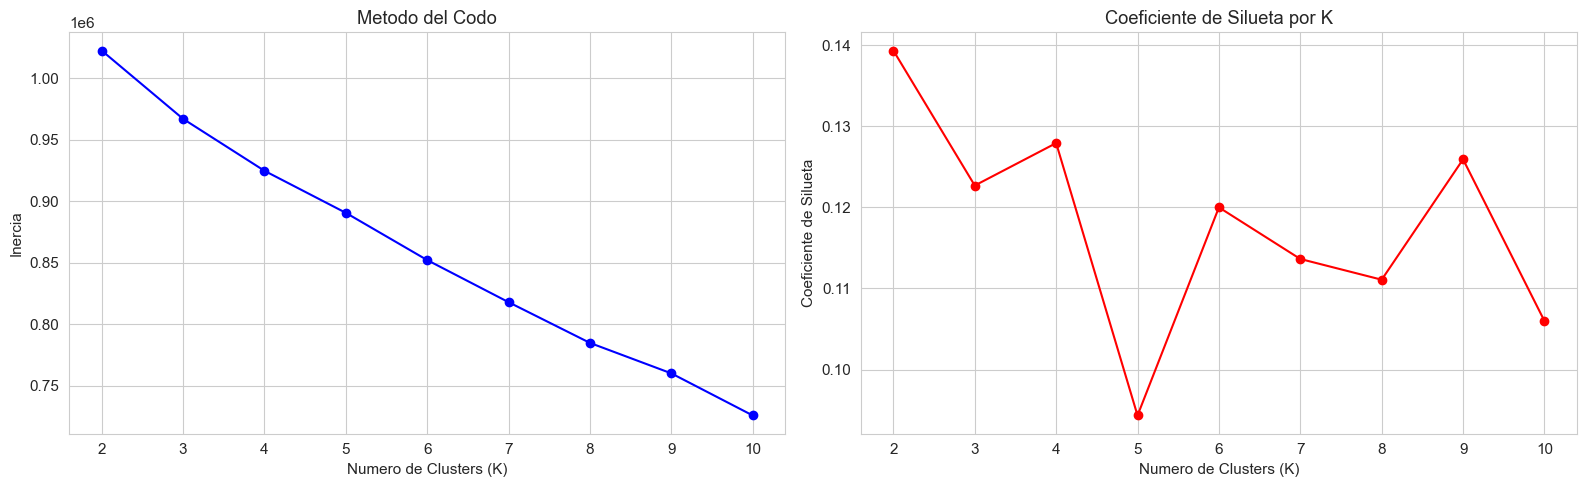

K optimo segun coeficiente de silueta: 2
Coeficiente de silueta para K=2: 0.1393

Distribucion de clusters (K=2):
cluster_kmeans
0    17058
1    18330
Name: count, dtype: int64


In [28]:
# Evaluar K de 2 a MAX_K_CLUSTERS (o n-1 si hay pocas observaciones)
max_k = min(MAX_K_CLUSTERS, X_scaled.shape[0] - 1)

if max_k >= 2:
    rango_k = range(2, max_k + 1)
    inercias = []
    siluetas = []

    for k in rango_k:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        inercias.append(km.inertia_)
        sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else 0
        siluetas.append(sil)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Metodo del codo
    axes[0].plot(list(rango_k), inercias, "b-o", markersize=6)
    axes[0].set_xlabel("Numero de Clusters (K)")
    axes[0].set_ylabel("Inercia")
    axes[0].set_title("Metodo del Codo")

    # Silueta
    axes[1].plot(list(rango_k), siluetas, "r-o", markersize=6)
    axes[1].set_xlabel("Numero de Clusters (K)")
    axes[1].set_ylabel("Coeficiente de Silueta")
    axes[1].set_title("Coeficiente de Silueta por K")

    plt.tight_layout()
    plt.show()

    # K optimo por silueta
    k_optimo = list(rango_k)[np.argmax(siluetas)]
    print(f"K optimo segun coeficiente de silueta: {k_optimo}")
    print(f"Coeficiente de silueta para K={k_optimo}: {max(siluetas):.4f}")

    # Asignar clusters con K optimo
    km_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
    df_encoded["cluster_kmeans"] = km_final.fit_predict(X_scaled)

    print(f"\nDistribucion de clusters (K={k_optimo}):")
    print(df_encoded["cluster_kmeans"].value_counts().sort_index())
else:
    print(f"AVISO: Solo {X_scaled.shape[0]} observaciones. K-Means requiere al menos 3.")
    print("Se omite el analisis de K-Means.")


## Fase 4.3.1 : Visualizacion de Clusters en Espacio PCA


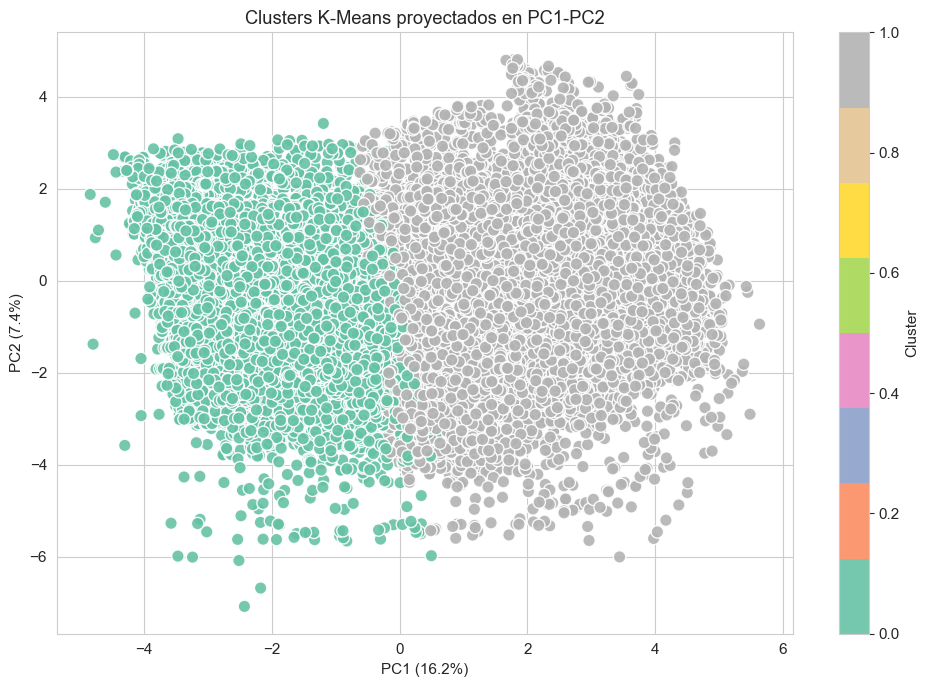

In [29]:
if "cluster_kmeans" in df_encoded.columns and X_pca.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=df_encoded["cluster_kmeans"],
        cmap="Set2",
        s=80,
        edgecolor="white",
        alpha=0.9
    )
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title("Clusters K-Means proyectados en PC1-PC2")
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()


# Fase 5 : Selección de Variables Relevantes (Enfoque de Ensamble No Supervisado)

Se implementa un **ensamble de tres métodos complementarios** de feature selection no supervisada. Ninguno de los tres requiere una variable objetivo, lo que los hace adecuados para el contexto del SGR donde no se dispone de una etiqueta de "proyecto exitoso/fallido" previa.

---

### Método 1 — Varianza Normalizada

Las variables con mayor dispersión (varianza) tras normalización Min-Max son las que más diferencian los proyectos entre sí. Una variable con varianza cercana a cero es estadísticamente inútil para segmentación o rankinig.

> Han, J., Kamber, M., & Pei, J. (2012). *Data Mining: Concepts and Techniques*. Morgan Kaufmann.

---

### Método 2 — Importancia PCA (Loadings Ponderados)

Se calcula la importancia de cada variable original como la suma ponderada del valor absoluto de sus loadings en los primeros componentes principales, usando la varianza explicada de cada componente como peso:

$$Importancia_{PCA}(v) = \sum_{k=1}^{K} \lambda_k \cdot |a_{vk}|$$

donde $\lambda_k$ es la proporción de varianza explicada por el componente $k$ y $a_{vk}$ es el loading de la variable $v$ en ese componente. Las variables que dominan los primeros componentes capturan la mayor parte de la estructura global del dataset.

> Jolliffe, I. T. (2002). *Principal Component Analysis* (2.ª ed.). Springer Series in Statistics. — Capítulo 6.

---

### Método 3 — Laplacian Score

El Laplacian Score mide la capacidad de cada variable para **preservar la estructura local** del grafo de $k$-vecinos más cercanos. Un score bajo indica que la variable es "suave" respecto a la geometría local: puntos cercanos en el espacio multidimensional tienden a tener valores similares en esa variable.

La fórmula es:

$$LS(f) = \frac{\tilde{f}^T L \tilde{f}}{\tilde{f}^T D \tilde{f}}$$

donde $L = D - W$ es la matriz Laplaciana del grafo, $D$ es la matriz diagonal de grados, $W$ es la matriz de adyacencia del grafo de $k$-vecinos, y $\tilde{f}$ es la variable centrada respecto al grafo.

> **He, X., Cai, D., & Niyogi, P. (2005). Laplacian Score for Feature Selection. *Advances in Neural Information Processing Systems (NIPS)*, 18, 507-514.** — Paper original del método.

---

### Consolidación: Score Compuesto por Promedio de Rangos (*Rank Aggregation*)

El score compuesto no es una fórmula arbitraria: es un **promedio de rangos**, técnica estándar en estadística no paramétrica. Al trabajar sobre posiciones ordinales en lugar de valores crudos, se elimina el problema de incomparabilidad de escalas entre los tres métodos.

$$Score\_compuesto(v) = \frac{Rango_{Varianza}(v) + Rango_{PCA}(v) + Rango_{Laplacian}(v)}{3}$$

Una variable debe ser consistentemente bien posicionada en los **tres criterios** para destacar en el ranking final, lo que le confiere mayor robustez que cualquier método individual.

> **Saeys, Y., Abeel, T., & Van de Peer, Y. (2008). Robust feature selection using ensemble feature selection techniques. ECML/PKDD. Springer.** — Fundamento del enfoque de ensamble.
>
> **Bolón-Canedo, V., & Alonso-Betanzos, A. (2019). Ensembles for feature selection. Springer.** — Marco teórico del consenso de métodos.


In [30]:
# =====================================================================
# METODO 1: Varianza Normalizada
# =====================================================================

# Usar MinMaxScaler para obtener varianza en rango [0,1]
mms = MinMaxScaler()
X_minmax = pd.DataFrame(
    mms.fit_transform(X),
    columns=X.columns
)
varianza_norm = X_minmax.var().sort_values(ascending=False)

print("METODO 1: Varianza Normalizada")
print(f"Top {min(TOP_N, len(varianza_norm))} variables:")
for var, val in varianza_norm.head(TOP_N).items():
    print(f"  {var}: {val:.6f}")


METODO 1: Varianza Normalizada
Top 15 variables:
  APROBACIÓN DEL PROYECTO_LEY DE APROBACIÓN: 0.248872
  EJECUCIÓN DEL PROYECTO_RANGO TOTAL PAGOS: 0.186613
  CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR: 0.181801
  CARACTERIZACIÓN DEL PROYECTO_SECTOR: 0.150706
  CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL: 0.148651
  CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE: 0.144057
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: 0.133137
  APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO: 0.131655
  CARACTERIZACIÓN DEL PROYECTO_REGION ENTIDAD QUE MÁS APORTA RECURSOS: 0.130235
  EJECUCIÓN DEL PROYECTO_OFICINA REGIONAL: 0.115766
  ENTIDAD EJECUTORA DEL PROYECTO_DIGITO VERIFICACIÓN: 0.103976
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN: 0.097081
  ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR: 0.086080
  ENTIDAD EJECUTORA DEL PROYECTO_DEPARTAMENTO EJECUTOR: 0.080488
  CARACTERIZACIÓN DEL PROYECTO_DEPARTAMENTO ENTIDAD QUE MÁS APORTA RECURSOS: 0.079930


In [31]:
# =====================================================================
# METODO 2: Importancia PCA (ya calculada en Fase 4.1.1)
# =====================================================================
print("METODO 2: Importancia PCA (Loadings Ponderados)")
print(f"Top {min(TOP_N, len(importancia_pca))} variables:")
for var, val in importancia_pca.head(TOP_N).items():
    print(f"  {var}: {val:.6f}")


METODO 2: Importancia PCA (Loadings Ponderados)
Top 15 variables:
  EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO: 0.152566
  CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE: 0.148040
  CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL: 0.146658
  ENTIDAD EJECUTORA DEL PROYECTO_CAPACIDAD INSTITUCIONAL: 0.144078
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR DETALLADO: 0.139089
  ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR: 0.138999
  APROBACIÓN DEL PROYECTO_TIPO DE INSTANCIA INICIAL: 0.135756
  ENTIDAD EJECUTORA DEL PROYECTO_TIPO EJECUTOR: 0.134601
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FINANCIERO: 0.134486
  CARACTERIZACIÓN DEL PROYECTO_CODIGO ENTIDAD TERRITORIAL QUE APORTA MÁS RECURSOS: 0.133342
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FISICO: 0.131866
  APROBACIÓN DEL PROYECTO_FECHA DE PUBLICACIÓN DE ACTO DE APROBACIÓN: 0.131211
  CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR: 0.128432
  EJECUCIÓN DEL PROYECTO_FECHA ACTA INICIO: 0.124253
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMA

In [32]:
# =====================================================================
# METODO 3: Laplacian Score
# =====================================================================

def calcular_laplacian_score(X, n_vecinos=5):
    """
    Calcula el Laplacian Score para cada variable.

    El Laplacian Score mide la suavidad de cada feature respecto al grafo
    de k-vecinos mas cercanos. Un score bajo indica que la variable
    preserva bien la estructura local (es informativa).

    Parametros
    ----------
    X : pd.DataFrame o np.array
        Datos estandarizados.
    n_vecinos : int
        Numero de vecinos para construir el grafo.

    Retorna
    -------
    pd.Series
        Laplacian Score por variable (menor = mas relevante).
    """
    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    n_samples, n_features = X_arr.shape

    # Construir grafo de k-vecinos (simetrico)
    n_neighbors_actual = min(n_vecinos, n_samples - 1)
    W = kneighbors_graph(X_arr, n_neighbors=n_neighbors_actual, mode="connectivity")
    W = 0.5 * (W + W.T)  # Simetrizar

    # Matriz de grado y Laplaciana
    D = np.array(W.sum(axis=1)).flatten()
    L = np.diag(D) - W.toarray()

    scores = np.zeros(n_features)
    ones = np.ones(n_samples)

    for j in range(n_features):
        f = X_arr[:, j]
        # Centrar respecto al grafo: f_tilde = f - (f^T D 1 / 1^T D 1) * 1
        f_tilde = f - (f @ D * ones.sum()) / (D.sum()) * ones
        # Laplacian Score = f_tilde^T L f_tilde / f_tilde^T D f_tilde
        numerador = f_tilde @ L @ f_tilde
        denominador = f_tilde @ (D * f_tilde)

        if denominador < 1e-10:
            scores[j] = np.inf  # Variable constante respecto al grafo
        else:
            scores[j] = numerador / denominador

    if isinstance(X, pd.DataFrame):
        return pd.Series(scores, index=X.columns)
    return scores


# Calcular Laplacian Score
n_vec = min(N_VECINOS_LAPLACIAN, X_scaled.shape[0] - 1)
lap_scores = calcular_laplacian_score(X_scaled, n_vecinos=n_vec)

# Menor score = mas relevante, invertir para ranking
# (usaremos 1/score para que mayor = mejor, consistente con los otros metodos)
lap_scores_inv = 1 / (lap_scores + 1e-10)
lap_scores_inv = lap_scores_inv.sort_values(ascending=False)

print("METODO 3: Laplacian Score (invertido: mayor = mas relevante)")
print(f"Top {min(TOP_N, len(lap_scores_inv))} variables:")
for var, val in lap_scores_inv.head(TOP_N).items():
    print(f"  {var}: {val:.6f}")


METODO 3: Laplacian Score (invertido: mayor = mas relevante)
Top 15 variables:
  CARACTERIZACIÓN DEL PROYECTO_PROYECTO TIPO: 10000004015.179499
  OTRAS VARIABLES DEL PROYECTO_PROYECTOS OBRAS DE INF. FÍSICA EN IPES: 9999996103.464346
  EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO: 6684164.419080
  EJECUCIÓN DEL PROYECTO_RANGO AVANCE FINANCIERO: 3534064.051552
  EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN: 2413409.496822
  APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO: 1678166.234446
  APROBACIÓN DEL PROYECTO_FECHA DE PUBLICACIÓN DE ACTO DE APROBACIÓN: 1523978.479448
  CARACTERIZACIÓN DEL PROYECTO_SECTOR: 1282511.602384
  CARACTERIZACIÓN DEL PROYECTO_REGION ENTIDAD QUE MÁS APORTA RECURSOS: 1059564.682201
  CARACTERIZACIÓN DEL PROYECTO_FECHA ESTADO DETALLE PROYECTO: 1046644.907159
  APROBACIÓN DEL PROYECTO_TIPO DE INSTANCIA INICIAL: 907741.579037
  APROBACIÓN DEL PROYECTO_LEY DE APROBACIÓN: 896095.084063
  EJECUCIÓN DEL PROYECTO_FECHA ACTA INICIO: 839791.184010
  CARA

# Fase 6 : Consolidacion y Ranking Cruzado de Variables Relevantes

Se construye un DataFrame resumen que cruza los rankings de los tres metodos:
Varianza Normalizada, Importancia PCA y Laplacian Score. Cada variable recibe un
ranking por metodo (1 = mas relevante) y un score compuesto que es el promedio de
los tres rankings. Las variables que aparecen consistentemente en posiciones altas
en los tres metodos son las mas informativas para describir la estructura de los datos.


In [33]:
# =====================================================================
# CONSTRUCCION DEL RANKING CRUZADO
# =====================================================================

# DataFrame base con todas las variables
all_vars = X.columns.tolist()

# Ranking Varianza (1 = mayor varianza)
rank_var = varianza_norm.rank(ascending=False).astype(int)

# Ranking PCA (1 = mayor importancia)
rank_pca = importancia_pca.rank(ascending=False).astype(int)

# Ranking Laplacian (1 = mayor score invertido = menor Laplacian Score)
rank_lap = lap_scores_inv.rank(ascending=False).astype(int)

# Consolidar
resumen = pd.DataFrame({
    "Variable": all_vars,
    "Varianza_Norm": [varianza_norm.get(v, 0) for v in all_vars],
    "Rank_Varianza": [rank_var.get(v, len(all_vars)) for v in all_vars],
    "Importancia_PCA": [importancia_pca.get(v, 0) for v in all_vars],
    "Rank_PCA": [rank_pca.get(v, len(all_vars)) for v in all_vars],
    "Laplacian_Inv": [lap_scores_inv.get(v, 0) for v in all_vars],
    "Rank_Laplacian": [rank_lap.get(v, len(all_vars)) for v in all_vars],
})

# Score compuesto: promedio de rankings (menor = mejor)
resumen["Score_Compuesto"] = resumen[["Rank_Varianza", "Rank_PCA", "Rank_Laplacian"]].mean(axis=1)
resumen = resumen.sort_values("Score_Compuesto").reset_index(drop=True)

print("=" * 90)
print(f"TOP {min(TOP_N, len(resumen))} VARIABLES MAS RELEVANTES - RANKING CRUZADO NO SUPERVISADO")
print("=" * 90)
print(resumen.head(TOP_N)[[
    "Variable", "Rank_Varianza", "Rank_PCA", "Rank_Laplacian", "Score_Compuesto"
]].to_string(index=False))


TOP 15 VARIABLES MAS RELEVANTES - RANKING CRUZADO NO SUPERVISADO
                                                           Variable  Rank_Varianza  Rank_PCA  Rank_Laplacian  Score_Compuesto
                        CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL              5         3              16         8.000000
                           EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO             24         1               3         9.333333
                        CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE              6         2              24        10.666667
   EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN             12        15               5        10.666667
                                CARACTERIZACIÓN DEL PROYECTO_SECTOR              4        21               8        11.000000
                  APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO              8        19               6        11.000000
                          APROBACIÓN DEL PROYECTO_LEY

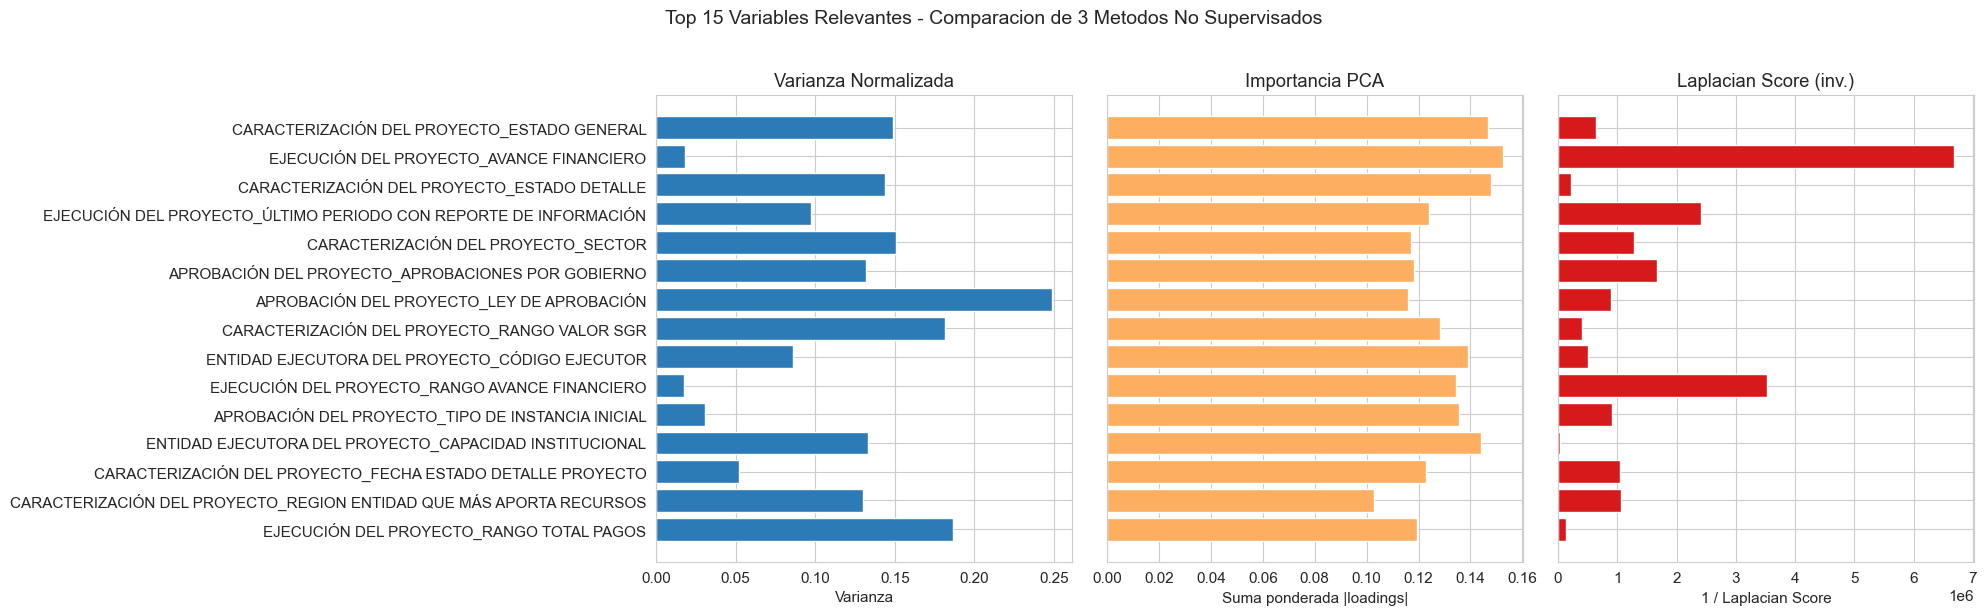

In [34]:
# =====================================================================
# VISUALIZACION COMPARATIVA
# =====================================================================

top_resumen = resumen.head(min(TOP_N, len(resumen))).copy()

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(top_resumen) * 0.4)), sharey=True)

# Panel 1: Varianza Normalizada
axes[0].barh(
    top_resumen["Variable"][::-1],
    top_resumen["Varianza_Norm"][::-1],
    color="#2c7bb6", edgecolor="white"
)
axes[0].set_title("Varianza Normalizada")
axes[0].set_xlabel("Varianza")

# Panel 2: Importancia PCA
axes[1].barh(
    top_resumen["Variable"][::-1],
    top_resumen["Importancia_PCA"][::-1],
    color="#fdae61", edgecolor="white"
)
axes[1].set_title("Importancia PCA")
axes[1].set_xlabel("Suma ponderada |loadings|")

# Panel 3: Laplacian Score (invertido)
axes[2].barh(
    top_resumen["Variable"][::-1],
    top_resumen["Laplacian_Inv"][::-1],
    color="#d7191c", edgecolor="white"
)
axes[2].set_title("Laplacian Score (inv.)")
axes[2].set_xlabel("1 / Laplacian Score")

plt.suptitle(
    f"Top {len(top_resumen)} Variables Relevantes - Comparacion de 3 Metodos No Supervisados",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()


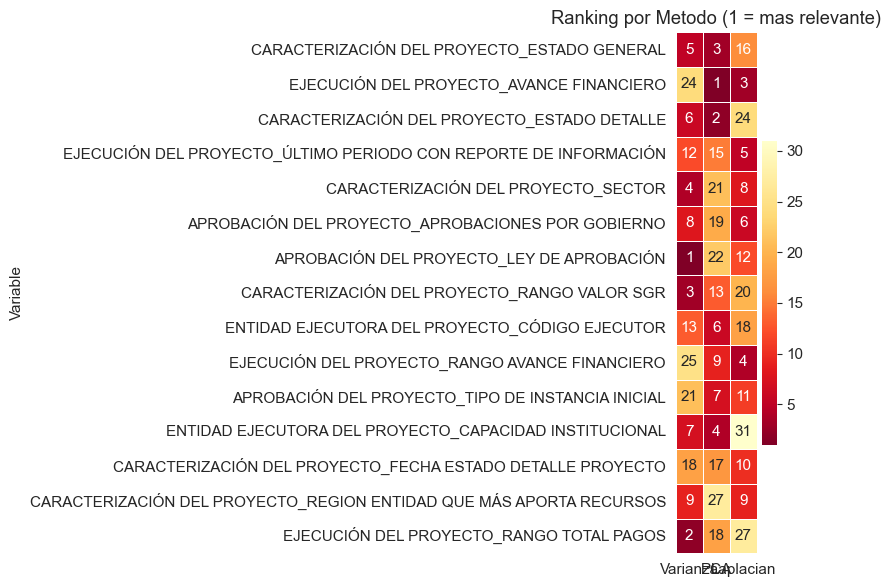

In [35]:
# =====================================================================
# HEATMAP DEL RANKING CRUZADO
# =====================================================================

top_para_heat = resumen.head(min(TOP_N, len(resumen))).set_index("Variable")
rank_cols = ["Rank_Varianza", "Rank_PCA", "Rank_Laplacian"]

fig, ax = plt.subplots(figsize=(8, max(5, len(top_para_heat) * 0.4)))
sns.heatmap(
    top_para_heat[rank_cols],
    annot=True,
    fmt=".0f",
    cmap="YlOrRd_r",  # Invertido: ranking bajo (bueno) = color claro
    linewidths=0.5,
    ax=ax
)
ax.set_title("Ranking por Metodo (1 = mas relevante)")
ax.set_xticklabels(["Varianza", "PCA", "Laplacian"], rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# =====================================================================
# EXPORTAR RESUMEN A CSV
# =====================================================================
resumen.to_csv(RUTA_SALIDA, index=False, encoding="utf-8-sig")
print(f"Resumen exportado a: {RUTA_SALIDA}")
print(f"Total variables analizadas: {len(resumen)}")
print(f"Top {min(TOP_N, len(resumen))}: {len(top_resumen)} variables seleccionadas")


## Fase 6.1 : Perfil de Clusters por Variables Top

Utilizando las variables mejor rankeadas y los clusters asignados por K-Means,
se genera un perfil descriptivo que muestra los valores promedio de cada variable
top dentro de cada cluster. Esto permite interpretar que caracteriza a cada grupo
de proyectos.


Perfil de Clusters (media por variable top):
cluster_kmeans                                                               0             1
CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL                       2.924200e+00  1.939716e+00
EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO                          9.657872e+01  7.517596e+01
CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE                       7.867276e-01  2.496508e+00
EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN  1.595514e+06  1.746805e+06
CARACTERIZACIÓN DEL PROYECTO_SECTOR                               1.437232e+01  1.292510e+01
APROBACIÓN DEL PROYECTO_APROBACIONES POR GOBIERNO                 9.147028e-01  2.680251e+00
APROBACIÓN DEL PROYECTO_LEY DE APROBACIÓN                         4.162270e-03  8.963993e-01
CARACTERIZACIÓN DEL PROYECTO_RANGO VALOR SGR                      3.390960e+00  2.562302e+00
ENTIDAD EJECUTORA DEL PROYECTO_CÓDIGO EJECUTOR                    4.163080e+05  2.893956e+06
EJECUCIÓN DEL PROYECTO_RA

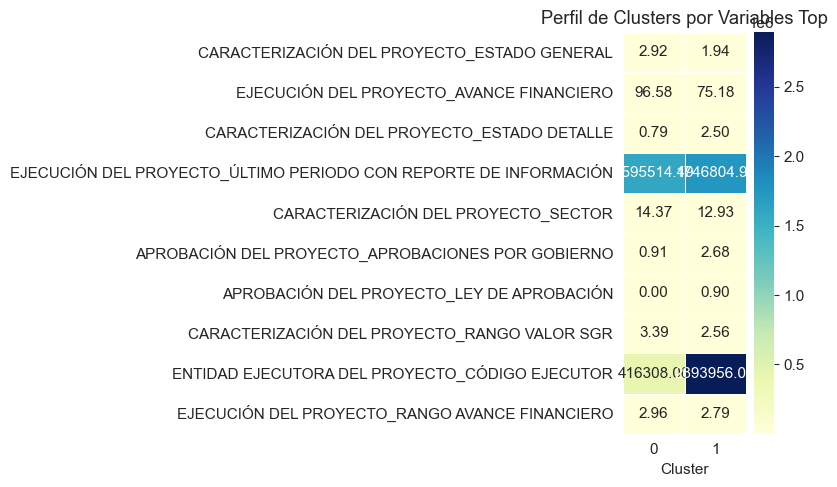

In [37]:
if "cluster_kmeans" in df_encoded.columns:
    # Seleccionar top variables del ranking
    top_vars_perfil = resumen.head(min(10, len(resumen)))["Variable"].tolist()
    top_vars_disponibles = [v for v in top_vars_perfil if v in df_encoded.columns]

    if top_vars_disponibles:
        perfil = df_encoded.groupby("cluster_kmeans")[top_vars_disponibles].mean()

        print("Perfil de Clusters (media por variable top):")
        print(perfil.T.to_string())

        # Heatmap del perfil
        fig, ax = plt.subplots(figsize=(max(8, perfil.shape[0] * 2), max(5, len(top_vars_disponibles) * 0.5)))
        sns.heatmap(
            perfil.T,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            linewidths=0.5,
            ax=ax
        )
        ax.set_title("Perfil de Clusters por Variables Top")
        ax.set_xlabel("Cluster")
        plt.tight_layout()
        plt.show()
else:
    print("No se ejecuto K-Means. Omitiendo perfil de clusters.")


## Fase 6.2 : Diccionario de Datos de Variables Seleccionadas

Esta sección genera automáticamente un **diccionario de datos** para las variables que resultaron del pipeline. El diccionario incluye los campos requeridos para trazabilidad metodológica y mantenimiento futuro de la herramienta.

> Recomendación del diagnóstico institucional DNP: construir un diccionario de datos que incluya nombre, descripción conceptual, fuente, tipo, periodicidad y relación con las dimensiones del score.


In [39]:
# =====================================================================
# DICCIONARIO DE DATOS — VARIABLES SELECCIONADAS
# =====================================================================

# Variables finales del ranking
variables_finales = resumen["Variable"].tolist()

# Metadatos inferidos automáticamente del dataset
dict_datos = []
for var in variables_finales:
    # Extraer grupo temático y nombre corto del header compuesto
    partes = var.split("_", 1)
    grupo = partes[0].strip() if len(partes) > 1 else "SIN_GRUPO"
    nombre_corto = partes[1].strip() if len(partes) > 1 else var

    # Tipo de dato en el dataset original (antes de encoding)
    if var in df_raw.columns:
        tipo_orig = str(df_raw[var].dtype)
        n_unicos = df_raw[var].nunique()
        ejemplo = str(df_raw[var].dropna().iloc[0]) if df_raw[var].count() > 0 else "N/D"
    else:
        tipo_orig = "codificada"
        n_unicos = "N/D"
        ejemplo = "N/D"

    # Score y ranking del ensamble
    fila_resumen = resumen[resumen["Variable"] == var]
    score = fila_resumen["Score_Compuesto"].values[0] if len(fila_resumen) > 0 else 99
    rank_v = int(fila_resumen["Rank_Varianza"].values[0]) if len(fila_resumen) > 0 else 99
    rank_p = int(fila_resumen["Rank_PCA"].values[0])      if len(fila_resumen) > 0 else 99
    rank_l = int(fila_resumen["Rank_Laplacian"].values[0]) if len(fila_resumen) > 0 else 99

    dict_datos.append({
        "Variable (nombre completo)": var,
        "Grupo temático": grupo,
        "Nombre corto": nombre_corto,
        "Tipo de dato original": tipo_orig,
        "Cardinalidad (# únicos)": n_unicos,
        "Ejemplo de valor": ejemplo[:50],
        "Fuente": "Base de Proyectos SGR — Hoja: PROYECTOS APROBADOS",
        "Periodicidad actualización": "Variable (según reporte de avance del proyecto)",
        "Score Compuesto (menor=mejor)": round(score, 2),
        "Rank Varianza": rank_v,
        "Rank PCA": rank_p,
        "Rank Laplacian Score": rank_l,
        "Dimensión del score SGR": grupo.title(),
    })

df_diccionario = pd.DataFrame(dict_datos)

print("=" * 80)
print("DICCIONARIO DE DATOS — VARIABLES SELECCIONADAS POR EL PIPELINE")
print("=" * 80)
print(df_diccionario[[
    "Variable (nombre completo)", "Grupo temático", "Tipo de dato original",
    "Cardinalidad (# únicos)", "Score Compuesto (menor=mejor)"
]].to_string(index=False))

# Exportar diccionario
ruta_dict = RUTA_SALIDA.parent / "diccionario_de_datos.csv"
df_diccionario.to_csv(ruta_dict, index=False, encoding="utf-8-sig")
print(f"\n✅ Diccionario exportado")


DICCIONARIO DE DATOS — VARIABLES SELECCIONADAS POR EL PIPELINE
                                                     Variable (nombre completo)                 Grupo temático Tipo de dato original  Cardinalidad (# únicos)  Score Compuesto (menor=mejor)
                                    CARACTERIZACIÓN DEL PROYECTO_ESTADO GENERAL   CARACTERIZACIÓN DEL PROYECTO                   str                        4                           8.00
                                       EJECUCIÓN DEL PROYECTO_AVANCE FINANCIERO         EJECUCIÓN DEL PROYECTO               float64                     5064                           9.33
                                    CARACTERIZACIÓN DEL PROYECTO_ESTADO DETALLE   CARACTERIZACIÓN DEL PROYECTO                   str                        8                          10.67
               EJECUCIÓN DEL PROYECTO_ÚLTIMO PERIODO CON REPORTE DE INFORMACIÓN         EJECUCIÓN DEL PROYECTO        datetime64[us]                      127                        

# Resumen Ejecutivo del Pipeline

## Etapas completadas

1. **Ingesta:** lectura del archivo Excel con headers multinivel y aplanamiento
   automatico de nombres de columna preservando la jerarquia de grupos.
2. **Limpieza:** eliminacion de columnas por umbral de nulidad (configurable),
   imputacion por mediana/moda, remocion de variables con varianza cercana a cero,
   y Label Encoding con documentacion de variables ordinales vs. nominales.
3. **Validacion de normalidad:** prueba de Shapiro-Wilk por variable para determinar
   si Pearson o Spearman es la metrica de correlacion adecuada.
4. **Correlacion y VIF:** deteccion de pares altamente correlacionados (Pearson y
   Spearman), eliminacion iterativa por VIF (con nota sobre su limitacion a
   multicolinealidad lineal).
5. **Deteccion de outliers multivariados:** distancia de Mahalanobis con comparacion
   del impacto en PCA (loadings y varianza explicada con y sin outliers).
6. **Validacion de supuestos para PCA:** test de esfericidad de Bartlett y
   Kaiser-Meyer-Olkin (KMO) global y por variable.
7. **Analisis exploratorio:** PCA con scree plot y Analisis Paralelo de Horn para
   seleccion rigurosa del numero de componentes; clustering jerarquico con
   coeficiente cofenetico; test de Hopkins para validar tendencia al agrupamiento;
   y K-Means con seleccion automatica de K por silueta.
8. **Feature Selection no supervisada:** ranking cruzado de tres metodos (Varianza
   Normalizada, Loadings PCA ponderados y Laplacian Score) que identifican las
   variables mas informativas sin necesidad de una variable objetivo.

## Interpretacion del Ranking

Las variables con un Score Compuesto bajo (cercano a 1) aparecen consistentemente
en las primeras posiciones de los tres metodos, lo que indica que:
- tienen alta dispersion (varianza),
- capturan la mayor proporcion de la estructura del dataset (PCA), y
- preservan bien la geometria local de los datos (Laplacian).

Estas son las variables que mas diferencian los proyectos entre si y que mayor
poder descriptivo tienen para segmentacion y analisis posterior.

## Notas para el usuario

- El archivo ranking_variables_no_supervisado.csv contiene el resumen completo.
- Los umbrales UMBRAL_NULOS, UMBRAL_VARIANZA, UMBRAL_VIF y N_VECINOS_LAPLACIAN
  son configurables en la seccion de variables globales.
- Si en el futuro se define una variable objetivo, el notebook original con
  Random Forest, SHAP y LASSO sigue disponible.


---

# Referencias Bibliográficas

Las siguientes referencias sustentan las decisiones metodológicas de este pipeline:

1. **Saeys, Y., Abeel, T., & Van de Peer, Y. (2008).** Robust feature selection using ensemble feature selection techniques. In *Joint European Conference on Machine Learning and Knowledge Discovery in Databases* (pp. 313–325). Springer, Berlin, Heidelberg.
   → Fundamento del enfoque de **ensamble de métodos** de selección de variables.

2. **Bolón-Canedo, V., & Alonso-Betanzos, A. (2019).** *Ensembles for feature selection*. Springer International Publishing.
   → Marco teórico del **consenso y agregación de rankings** en feature selection.

3. **He, X., Cai, D., & Niyogi, P. (2005).** Laplacian score for feature selection. *Advances in Neural Information Processing Systems (NIPS)*, 18, 507–514.
   → Paper original del **Laplacian Score** (Método 3 del pipeline).

4. **Jolliffe, I. T. (2002).** *Principal Component Analysis* (2.ª ed.). Springer Series in Statistics. New York.
   → Fundamento del **PCA** y del uso de loadings para selección de variables (Capítulo 6: *Choosing a Subset of Principal Components or Variables*).

5. **Han, J., Kamber, M., & Pei, J. (2012).** *Data Mining: Concepts and Techniques* (3.ª ed.). Morgan Kaufmann.
   → Fundamento del **preprocesamiento** (nulos, imputación, varianza) y **normalización Min-Max** (§3.2, §3.5).

### Referencias adicionales (Validación de Supuestos)

- **Shapiro, S. S., & Wilk, M. B. (1965).** An analysis of variance test for normality (complete samples). *Biometrika*, 52(3-4), 591–611.
  → Fundamento del **test de Shapiro-Wilk** para verificar normalidad antes de Pearson.

- **Razali, N. M., & Wah, Y. B. (2011).** Power comparisons of Shapiro-Wilk, Kolmogorov-Smirnov, Lilliefors and Anderson-Darling tests. *Journal of Statistical Modeling and Analytics*, 2(1), 21–33.
  → Justificación de **Shapiro-Wilk sobre Kolmogorov-Smirnov** para n < 5000.

- **Bartlett, M. S. (1950).** Tests of significance in factor analysis. *British Journal of Statistical Psychology*, 3(2), 77–85.
  → Fundamento del **test de esfericidad de Bartlett** como prerrequisito de PCA.

- **Kaiser, H. F. (1970).** A second generation little jiffy. *Psychometrika*, 35(4), 401–415.
  → Fundamento del **índice KMO** (Kaiser-Meyer-Olkin) para adecuación muestral.

- **Horn, J. L. (1965).** A rationale and test for the number of factors in factor analysis. *Psychometrika*, 30(2), 179–185.
  → Fundamento del **Análisis Paralelo** para selección del número de componentes.

- **Mahalanobis, P. C. (1936).** On the generalized distance in statistics. *Proceedings of the National Institute of Sciences of India*, 2(1), 49–55.
  → Fundamento de la **distancia de Mahalanobis** para detección de outliers multivariados.

- **Hopkins, B., & Skellam, J. G. (1954).** A new method for determining the type of distribution of plant individuals. *Annals of Botany*, 18(2), 213–227.
  → Fundamento del **test de Hopkins** para evaluar tendencia al agrupamiento.

- **Sokal, R. R., & Rohlf, F. J. (1962).** The comparison of dendrograms by objective methods. *Taxon*, 11(2), 33–40.
  → Fundamento del **coeficiente de correlación cofenética** para validar dendrogramas.
